# Benchmark: pykarambola vs C++ karambola — AdrenalMNIST3D


**Dataset:** AdrenalMNIST3D — 1,584 adrenal gland meshes (train 1,188 / val 98 / test 298),
two resolutions (28³ and 64³ voxels), center-of-mass aligned to origin.

**What this notebook does:**
1. Parses pre-computed C++ karambola result folders into CSVs
2. Runs pykarambola on the same `.off` meshes (timed)
3. Reports wall-clock times 
4. Plots numerical agreement figures  

## Environment

In [1]:
import numpy as np
import pandas as pd
import os
import re
import glob
import time
import platform
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn

import pykarambola

In [2]:
# pykarambola version
print(f"pykarambola version : {pykarambola.__version__}")

# Machine details
print(f"Python              : {platform.python_version()}")
print(f"OS                  : {platform.system()} {platform.release()}")
print(f"Machine             : {platform.machine()}")
try:
    chip = subprocess.run(
        ['sysctl', '-n', 'machdep.cpu.brand_string'],
        capture_output=True, text=True
    ).stdout.strip()
    if not chip:
        chip = platform.processor()
except Exception:
    chip = platform.processor()
print(f"Chip                : {chip}")
print(f"Logical cores       : {os.cpu_count()}")
try:
    phys = subprocess.run(
        ['sysctl', '-n', 'hw.physicalcpu'],
        capture_output=True, text=True
    ).stdout.strip()
    print(f"Physical cores      : {phys}")
except Exception:
    pass

pykarambola version : 0.5.0
Python              : 3.13.13
OS                  : Darwin 24.6.0
Machine             : arm64
Chip                : Apple M4
Logical cores       : 10
Physical cores      : 10


## Configuration

In [3]:
assert Path.cwd().name == 'notebooks', (
    f"Expected CWD to be 'paper/notebooks/', got: {Path.cwd()}\n"
    "Please launch Jupyter from the paper/notebooks/ directory."
)

CHANNELS   = ['28', '64']
SPLITS     = ['train', 'validation', 'test']
SCALAR_KEYS = ['w000', 'w100', 'w200', 'w300']
VECTOR_KEYS = ['w010', 'w110', 'w210', 'w310']
TENSOR_KEYS = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']

# Input meshes
BASE_MESH_PATH = '../../dataset/medmnist_benchmarking/adrenal3d'

# C++ karambola result folders and log
BASE_KARA_PATH = '../../dataset/karambola_results/medmnist_benchmarking/adrenal3d'
_logs  = sorted(glob.glob(os.path.join(BASE_KARA_PATH, 'run_karambola_*.log')))
KARA_LOG = _logs[-1] if _logs else None
if KARA_LOG:
    print(f"Using karambola log: {os.path.basename(KARA_LOG)}")
else:
    print("Warning: no karambola log file found in", BASE_KARA_PATH)

# Higher-rank karambola results (w103, w104_eigval)
BASE_KARA_PATH_HIGHER_RANK = '../../dataset/karambola_results/medmnist_benchmarking/adrenal3d_higher_rank'
_logs_hr = sorted(glob.glob(os.path.join(BASE_KARA_PATH_HIGHER_RANK, 'run_karambola_*.log')))
KARA_LOG_HIGHER_RANK = _logs_hr[-1] if _logs_hr else None
if KARA_LOG_HIGHER_RANK:
    print(f"Using higher-rank log: {os.path.basename(KARA_LOG_HIGHER_RANK)}")

# Where to write CSVs and figures
FIGURES_PATH   = 'results'
os.makedirs(FIGURES_PATH, exist_ok=True)

Using karambola log: run_karambola_adrenal_3d_2026-05-25_01-12-09.log
Using higher-rank log: run_karambola_adrenal3d_higher_rank_2026-05-23_21-32-17.log


## Helper functions

In [4]:
def drop_symmetric_duplicates(df):
    """Drop redundant off-diagonal symmetric columns (e.g. w020_10 when w020_01 == w020_10)."""
    pattern = re.compile(r'^(w\d{3})_(\d)(\d)$')
    seen, to_drop = set(), []
    for col in df.columns:
        m = pattern.match(col)
        if m:
            tensor, i, j = m.groups()
            sym = f'{tensor}_{j}{i}'
            if i != j and sym in df.columns and (col, sym) not in seen and (sym, col) not in seen:
                seen.add((col, sym))
                if (df[col] == df[sym]).all():
                    to_drop.append(sym)
    return df.drop(columns=to_drop)


def parse_filename(fname):
    """Parse '{split}_image_{num}_label_{label}' folder/file names.
    Returns (split, image_num_str, label_int) or None if not matched.
    """
    m = re.match(r'^(\w+?)_image_(\d+)_label_(\d+)$', fname)
    if m:
        return m.group(1), m.group(2), int(m.group(3))
    return None


def parse_karambola_folder(folder_path):
    """Read all karambola output files from a single mesh result folder.
    Returns a dict of raw values or None if files are missing.
    """
    data = {
        'w000': None, 'w100': None, 'w200': None, 'w300': None,
        'w010': [None]*3, 'w110': [None]*3, 'w210': [None]*3, 'w310': [None]*3,
    }
    for t in TENSOR_KEYS:
        data[t] = [[None]*3 for _ in range(3)]
        data[f'{t}_eig'] = [None]*3

    # Scalars
    fp = os.path.join(folder_path, 'w000_w100_w200_w300')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#'): continue
                cols = line.split()
                if len(cols) > 2 and cols[2] in data:
                    data[cols[2]] = float(cols[1])

    # Vectors
    fp = os.path.join(folder_path, 'w010_w110_w210_w310')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#'): continue
                cols = line.split()
                if len(cols) > 4 and cols[4] in data:
                    data[cols[4]] = [float(cols[1]), float(cols[2]), float(cols[3])]

    # Rank-2 tensors
    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, t)
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#'): continue
                    cols = line.split()
                    if len(cols) > 10 and cols[10] == t:
                        data[t] = [
                            [float(cols[1]), float(cols[2]), float(cols[3])],
                            [float(cols[4]), float(cols[5]), float(cols[6])],
                            [float(cols[7]), float(cols[8]), float(cols[9])],
                        ]

    # Eigensystems
    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, f'{t}_eigsys')
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#') or 'ALL' not in line: continue
                    parts = line.split()
                    ev = sorted([float(parts[1]), float(parts[5]), float(parts[9])])
                    data[f'{t}_eig'] = ev

    # MSM (msm_ql / msm_wl)
    data['msm_ql'] = [None] * 9
    data['msm_wl'] = [None] * 9
    fp = os.path.join(folder_path, 'msm_ql')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#') or 'ALL' not in line:
                    continue
                cols = line.split()
                data['msm_ql'] = [float(cols[i]) for i in range(1, 18, 2)]
                data['msm_wl'] = [float(cols[i]) for i in range(2, 19, 2)]
    return data


def build_row(data, image_num, label, split):
    """Flatten a parse_karambola_folder result dict into a flat record dict."""
    row = {'image_num': image_num, 'label': label, 'subfolder': split}
    for k in SCALAR_KEYS:
        row[k] = data[k]
    for vk in VECTOR_KEYS:
        for i in range(3):
            row[f'{vk}_{i}'] = data[vk][i]
    for tk in TENSOR_KEYS:
        for i in range(3):
            for j in range(3):
                row[f'{tk}_{i}{j}'] = data[tk][i][j]
        eigs = np.array(data[f'{tk}_eig'], dtype=float)
        for n, ev in enumerate(eigs, 1):
            row[f'{tk}_EVal{n}'] = ev
    for n, v in enumerate(data['msm_ql']):
        row[f'msm_ql_{n}'] = v if v is not None else float('nan')
    for n, v in enumerate(data['msm_wl']):
        row[f'msm_wl_{n}'] = v if v is not None else float('nan')
    return row


def parse_karambola_folder_higher_rank(folder_path):
    """Parse w103, w104_eigval, and msm_ql from a higher-rank karambola result folder."""
    data = {
        'w103': [float('nan')] * 27,
        'w104_eigval': [float('nan')] * 6,
        'msm_ql': [None] * 9,
        'msm_wl': [None] * 9,
    }

    # w103: 27 components m(i,j,k), cols 1-27
    fp = os.path.join(folder_path, 'w103')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#') or 'ALL' not in line:
                    continue
                cols = line.split()
                data['w103'] = [float(cols[i]) for i in range(1, 28)]

    # w104_eigval: 6 eigenvalues ev0..ev5, cols 1-6
    fp = os.path.join(folder_path, 'w104_eigval')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#') or 'ALL' not in line:
                    continue
                cols = line.split()
                data['w104_eigval'] = [float(cols[i]) for i in range(1, 7)]

    # MSM
    fp = os.path.join(folder_path, 'msm_ql')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#') or 'ALL' not in line:
                    continue
                cols = line.split()
                data['msm_ql'] = [float(cols[i]) for i in range(1, 18, 2)]
                data['msm_wl'] = [float(cols[i]) for i in range(2, 19, 2)]

    return data


def build_row_higher_rank(data, image_num, label, split):
    """Flatten a parse_karambola_folder_higher_rank result into a flat record dict."""
    row = {'image_num': image_num, 'label': label, 'subfolder': split}

    # w103 components
    idx = 0
    for i in range(3):
        for j in range(3):
            for k in range(3):
                row[f'w103_{i}{j}{k}'] = data['w103'][idx]
                idx += 1

    # w104 eigenvalues
    for n, v in enumerate(data['w104_eigval']):
        row[f'w104_EVal{n}'] = v

    # MSM
    for n, v in enumerate(data['msm_ql']):
        row[f'msm_ql_{n}'] = v if v is not None else float('nan')
    for n, v in enumerate(data['msm_wl']):
        row[f'msm_wl_{n}'] = v if v is not None else float('nan')

    return row


## Parse C++ karambola results

In [5]:
kara_times = {}

for channel in CHANNELS:
    kara_path = os.path.join(BASE_KARA_PATH, f'adrenal3d_{channel}')

    t0 = time.perf_counter()
    records = []

    for split in SPLITS:
        split_path = os.path.join(kara_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        folders = [d for d in os.listdir(split_path)
                   if os.path.isdir(os.path.join(split_path, d))]

        n_parsed = 0
        for folder_name in folders:
            parsed = parse_filename(folder_name)
            if parsed is None:
                continue   # skip old-format folders
            _, image_num, label = parsed
            folder_path = os.path.join(split_path, folder_name)
            data = parse_karambola_folder(folder_path)
            records.append(build_row(data, image_num, label, split))
            n_parsed += 1

        print(f'  adrenal3d_{channel} / {split}: {n_parsed} folders parsed')

    elapsed = time.perf_counter() - t0
    kara_times[channel] = elapsed

    df_k = pd.DataFrame(records)
    df_k = drop_symmetric_duplicates(df_k)

    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv')
    df_k.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_k)} rows → {csv_path}')

    print(f'  Parse time: {elapsed:.1f} s\n')

  adrenal3d_28 / train: 1188 folders parsed
  adrenal3d_28 / validation: 98 folders parsed
  adrenal3d_28 / test: 298 folders parsed
  Saved 1584 rows → results/adrenal3d_28_karambola.csv
  Parse time: 2.5 s

  adrenal3d_64 / train: 1188 folders parsed
  adrenal3d_64 / validation: 98 folders parsed
  adrenal3d_64 / test: 298 folders parsed
  Saved 1584 rows → results/adrenal3d_64_karambola.csv
  Parse time: 2.5 s



## Parse C++ karambola higher-rank results (w103, w104_eigval, MSM)

In [6]:
kara_hr_records = {}

for channel in CHANNELS:
    hr_path = os.path.join(BASE_KARA_PATH_HIGHER_RANK, f'adrenal3d_{channel}')
    records = []

    for split in SPLITS:
        split_path = os.path.join(hr_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        folders = [d for d in os.listdir(split_path)
                   if os.path.isdir(os.path.join(split_path, d))]
        n_parsed = 0
        for folder_name in folders:
            parsed = parse_filename(folder_name)
            if parsed is None:
                continue
            _, image_num, label = parsed
            folder_path = os.path.join(split_path, folder_name)
            data = parse_karambola_folder_higher_rank(folder_path)
            records.append(build_row_higher_rank(data, image_num, label, split))
            n_parsed += 1
        print(f'  adrenal3d_{channel} / {split}: {n_parsed} folders parsed')

    df_hr = pd.DataFrame(records)
    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola_higher_rank.csv')
    df_hr.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_hr)} rows → {csv_path}')
    kara_hr_records[channel] = df_hr


  adrenal3d_28 / train: 1188 folders parsed
  adrenal3d_28 / validation: 98 folders parsed
  adrenal3d_28 / test: 298 folders parsed
  Saved 1584 rows → results/adrenal3d_28_karambola_higher_rank.csv
  adrenal3d_64 / train: 1188 folders parsed
  adrenal3d_64 / validation: 98 folders parsed
  adrenal3d_64 / test: 298 folders parsed
  Saved 1584 rows → results/adrenal3d_64_karambola_higher_rank.csv


In [7]:
# Parse C++ karambola wall-clock times from the run log
kara_log_times = {}   # channel -> total seconds (C++ compute time)
kara_split_times = {} # channel -> {split -> seconds}

with open(KARA_LOG) as f:
    current_channel = None
    for line in f:
        line = line.strip()
        # Track current resolution block
        m = re.match(r'^Resolution:\s+adrenal3d_(\d+)', line)
        if m:
            current_channel = m.group(1)
            kara_split_times[current_channel] = {}
            continue
        # Per-split time
        m = re.match(r'^Time for adrenal3d_\d+/(\w+):\s+(\d+)\s+seconds', line)
        if m and current_channel:
            kara_split_times[current_channel][m.group(1)] = int(m.group(2))
            continue
        # Total per resolution
        m = re.match(r'^Total time for adrenal3d_(\d+):\s+(\d+)\s+seconds', line)
        if m:
            kara_log_times[m.group(1)] = int(m.group(2))

print(f"C++ karambola runtimes (from log: {os.path.basename(KARA_LOG)})")
for ch in CHANNELS:
    splits = kara_split_times.get(ch, {})
    total  = kara_log_times.get(ch, 'N/A')
    print(f"  adrenal3d_{ch}: train={splits.get('train','?')}s  "
          f"validation={splits.get('validation','?')}s  "
          f"test={splits.get('test','?')}s  →  total={total}s")

C++ karambola runtimes (from log: run_karambola_adrenal_3d_2026-05-25_01-12-09.log)
  adrenal3d_28: train=22s  validation=2s  test=6s  →  total=31s
  adrenal3d_64: train=66s  validation=5s  test=16s  →  total=90s


## Run pykarambola

In [8]:
pyk_times = {}

for channel in CHANNELS:
    mesh_path = os.path.join(BASE_MESH_PATH, f'adrenal3d_{channel}')

    t0 = time.perf_counter()
    records = []

    for split in SPLITS:
        split_path = os.path.join(mesh_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        files = glob.glob(os.path.join(split_path, '*.off'))
        print(f'  adrenal3d_{channel} / {split}: {len(files)} meshes')

        for fpath in files:
            fname = os.path.splitext(os.path.basename(fpath))[0]
            parsed = parse_filename(fname)
            if parsed is None:
                print(f'    [skip] unrecognised filename: {fname}')
                continue
            _, image_num, label = parsed

            tri = pykarambola.parse_off_file(fpath)
            result = pykarambola.minkowski_tensors(tri)

            row = {'image_num': image_num, 'label': label, 'subfolder': split}
            for k in SCALAR_KEYS:
                row[k] = result[k]
            for vk in VECTOR_KEYS:
                for i in range(3):
                    row[f'{vk}_{i}'] = result[vk][i]
            for tk in TENSOR_KEYS:
                mat = result[tk]
                for i in range(3):
                    for j in range(3):
                        row[f'{tk}_{i}{j}'] = mat[i, j]
                eigvals = result[f'{tk}_eigvals']
                for n, ev in enumerate(sorted(eigvals), 1):
                    row[f'{tk}_EVal{n}'] = ev
            records.append(row)

    elapsed = time.perf_counter() - t0
    pyk_times[channel] = elapsed

    df_py = pd.DataFrame(records)
    df_py = drop_symmetric_duplicates(df_py)

    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv')
    df_py.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_py)} rows → {csv_path}')

    print(f'  Run time: {elapsed:.1f} s\n')

  adrenal3d_28 / train: 1188 meshes
  adrenal3d_28 / validation: 98 meshes
  adrenal3d_28 / test: 298 meshes
  Saved 1584 rows → results/adrenal3d_28_pykarambola.csv
  Run time: 11.3 s

  adrenal3d_64 / train: 1188 meshes
  adrenal3d_64 / validation: 98 meshes
  adrenal3d_64 / test: 298 meshes
  Saved 1584 rows → results/adrenal3d_64_pykarambola.csv
  Run time: 61.8 s



## Run pykarambola (compute='all') — accuracy comparison

In [9]:
pyk_all_records = {}

for channel in CHANNELS:
    mesh_path = os.path.join(BASE_MESH_PATH, f'adrenal3d_{channel}')
    records = []

    for split in SPLITS:
        split_path = os.path.join(mesh_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        files = glob.glob(os.path.join(split_path, '*.off'))
        print(f'  adrenal3d_{channel} / {split}: {len(files)} meshes')

        for fpath in files:
            fname = os.path.splitext(os.path.basename(fpath))[0]
            parsed = parse_filename(fname)
            if parsed is None:
                print(f'    [skip] unrecognised filename: {fname}')
                continue
            _, image_num, label = parsed

            tri = pykarambola.parse_off_file(fpath)
            result = pykarambola.minkowski_tensors(tri, compute='all')

            row = {'image_num': image_num, 'label': label, 'subfolder': split}
            for k in SCALAR_KEYS:
                row[k] = result[k]
            for vk in VECTOR_KEYS:
                for i in range(3):
                    row[f'{vk}_{i}'] = result[vk][i]
            for tk in TENSOR_KEYS:
                mat = result[tk]
                for i in range(3):
                    for j in range(3):
                        row[f'{tk}_{i}{j}'] = mat[i, j]
                eigvals = result[f'{tk}_eigvals']
                for n, ev in enumerate(sorted(eigvals), 1):
                    row[f'{tk}_EVal{n}'] = ev
            # w103: 27 components m(i,j,k)
            w103 = result['w103']
            for i in range(3):
                for j in range(3):
                    for k in range(3):
                        row[f'w103_{i}{j}{k}'] = w103[i, j, k]
            # w104: eigenvalues of 6x6 Voigt matrix (ev0..ev5)
            for n, ev in enumerate(result['w104_eigvals']):
                row[f'w104_EVal{n}'] = ev
            # msm
            for n, ql in enumerate(result['msm_ql']):
                row[f'msm_ql_{n}'] = ql
            for n, wl in enumerate(result['msm_wl']):
                row[f'msm_wl_{n}'] = wl
            records.append(row)

    df_all = pd.DataFrame(records)
    df_all = drop_symmetric_duplicates(df_all)

    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola_all.csv')
    df_all.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_all)} rows → {csv_path}')
    pyk_all_records[channel] = df_all


  adrenal3d_28 / train: 1188 meshes


/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_69213/286622860.py:25: UserWarning: Trace ratio for w320 (label 0): w300 is near zero; returning NaN.
  result = pykarambola.minkowski_tensors(tri, compute='all')


  adrenal3d_28 / validation: 98 meshes
  adrenal3d_28 / test: 298 meshes
  Saved 1584 rows → results/adrenal3d_28_pykarambola_all.csv
  adrenal3d_64 / train: 1188 meshes


/var/folders/zl/l0prjwwn0db0fm9nhs69bxgh0000gn/T/ipykernel_69213/286622860.py:25: UserWarning: Trace ratio for w320 (label 0): w300 is near zero; returning NaN.
  result = pykarambola.minkowski_tensors(tri, compute='all')


  adrenal3d_64 / validation: 98 meshes
  adrenal3d_64 / test: 298 meshes
  Saved 1584 rows → results/adrenal3d_64_pykarambola_all.csv


## Runtime comparison

In [11]:
print("Wall-clock times — AdrenalMNIST3D (1,584 meshes per resolution)")
print(f"{'Resolution':<16} {'C++ karambola':>18} {'pykarambola':>16} {'speedup':>10}")
print('-' * 64)

for ch in CHANNELS:
    k_t  = kara_log_times.get(ch, float('nan'))
    py_t = pyk_times.get(ch, float('nan'))
    speedup = k_t / py_t if py_t > 0 else float('nan')
    print(f"adrenal3d_{ch:<6}  {k_t:>14} s  {py_t:>12.1f} s  {speedup:>8.1f}×")

total_k  = sum(kara_log_times.values())
total_py = sum(pyk_times.values())
print('-' * 64)
print(f"{'Total':<16}  {total_k:>14} s  {total_py:>12.1f} s  {total_k/total_py:>8.1f}×")
print()
print(f"Log file: {os.path.basename(KARA_LOG)}")
print()
print("Note: C++ karambola time is total wall-clock time including I/O")
print("      (one output folder per mesh, written sequentially).")
print("      pykarambola time is pure Python compute (no file output).")

Wall-clock times — AdrenalMNIST3D (1,584 meshes per resolution)
Resolution            C++ karambola      pykarambola    speedup
----------------------------------------------------------------
adrenal3d_28                  31 s          11.3 s       2.8×
adrenal3d_64                  90 s          61.8 s       1.5×
----------------------------------------------------------------
Total                        121 s          73.1 s       1.7×

Log file: run_karambola_adrenal_3d_2026-05-25_01-12-09.log

Note: C++ karambola time is total wall-clock time including I/O
      (one output folder per mesh, written sequentially).
      pykarambola time is pure Python compute (no file output).


## Numerical accuracy

Load the CSVs, merge on mesh identity, and compute absolute differences between karambola and pykarambola for all 121 features.

In [12]:
merged = {}

for channel in CHANNELS:
    # Standard quantities + MSM (karambola) — note: MSM may be empty here
    df_k  = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv'))
    # Higher-rank: w103, w104_eigval, MSM (karambola higher_rank run has valid MSM)
    df_hr = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola_higher_rank.csv'))
    # pykarambola compute='all'
    df_py = pd.read_csv(os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola_all.csv'))

    # Merge karambola standard + higher-rank
    df_k_full = df_k.merge(df_hr, on=['image_num', 'label', 'subfolder'],
                           how='inner', suffixes=('', '_hr'))

    # For overlapping columns (e.g. msm_ql_*): prefer higher_rank if standard is all-NaN
    hr_dupes = [c for c in df_k_full.columns if c.endswith('_hr')]
    for col_hr in hr_dupes:
        col_base = col_hr[:-3]  # strip '_hr'
        if col_base in df_k_full.columns:
            if df_k_full[col_base].isna().all():
                df_k_full[col_base] = df_k_full[col_hr]
        df_k_full = df_k_full.drop(columns=[col_hr])

    # Merge karambola full reference vs pykarambola_all
    df_m = df_k_full.merge(df_py, on=['image_num', 'label', 'subfolder'],
                           suffixes=('_k', '_py'))
    merged[channel] = df_m
    print(f'adrenal3d_{channel}: {len(df_m)} matched rows, {len(df_m.columns)} columns')

    # Report MSM coverage
    msm_col = 'msm_ql_0_k'
    if msm_col in df_m.columns:
        n_valid = df_m[msm_col].notna().sum()
        print(f'  MSM coverage: {n_valid}/{len(df_m)} rows have karambola MSM data')


adrenal3d_28: 1584 matched rows, 251 columns
  MSM coverage: 1584/1584 rows have karambola MSM data
adrenal3d_64: 1584 matched rows, 251 columns
  MSM coverage: 1584/1584 rows have karambola MSM data


In [32]:
def abs_diff_summary(df_m, cols):
    """Absolute difference statistics between _k and _py columns across all meshes.

    Returns a DataFrame with max and mean absolute difference per feature,
    plus the max observed value for scale context.
    """
    rows = []
    for col in cols:
        if f'{col}_k' not in df_m.columns or f'{col}_py' not in df_m.columns:
            continue
        k   = df_m[f'{col}_k']
        py  = df_m[f'{col}_py']
        diff = (k - py).abs()
        rows.append({
            'feature':       col,
            'max_abs_diff':  diff.max(),
            'mean_abs_diff': diff.mean(),
            'max_val':       np.maximum(k.abs(), py.abs()).max(),
        })
    return pd.DataFrame(rows).set_index('feature')


### Figure 1 — Validation scatter: pykarambola vs C++ karambola

Saved → results/scatter_accuracy_paper.pdf


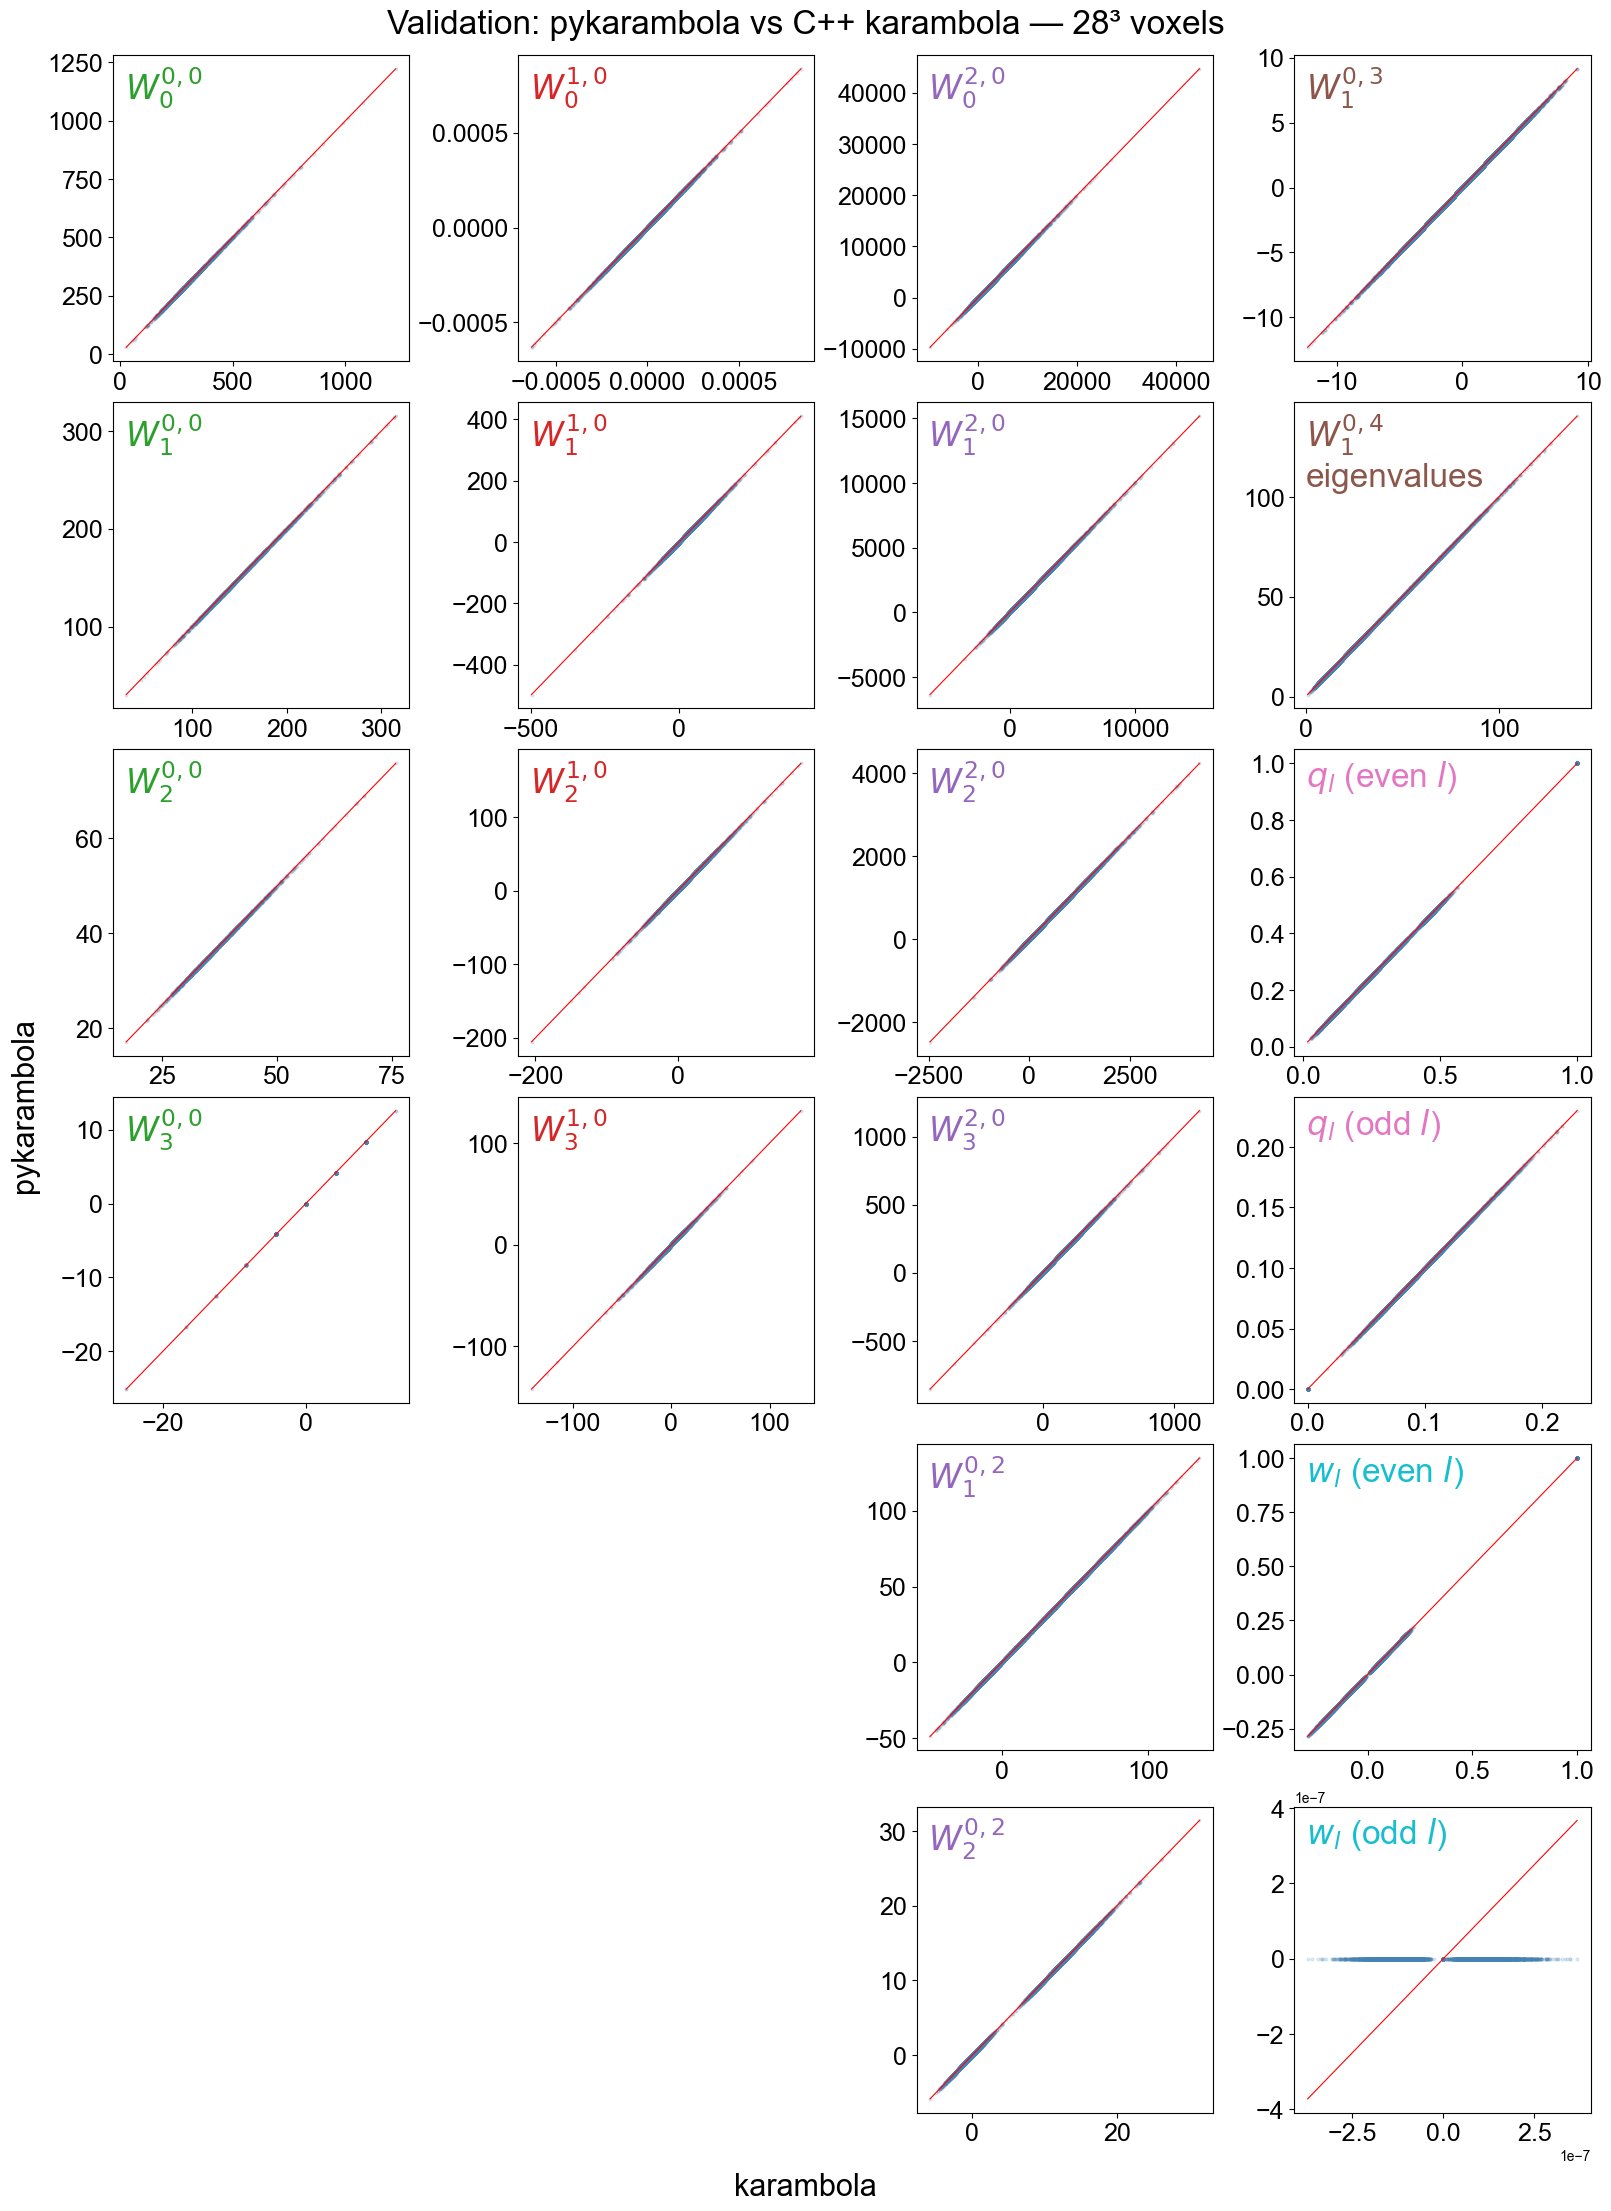

Saved → results/scatter_accuracy_paper_supplementary.pdf


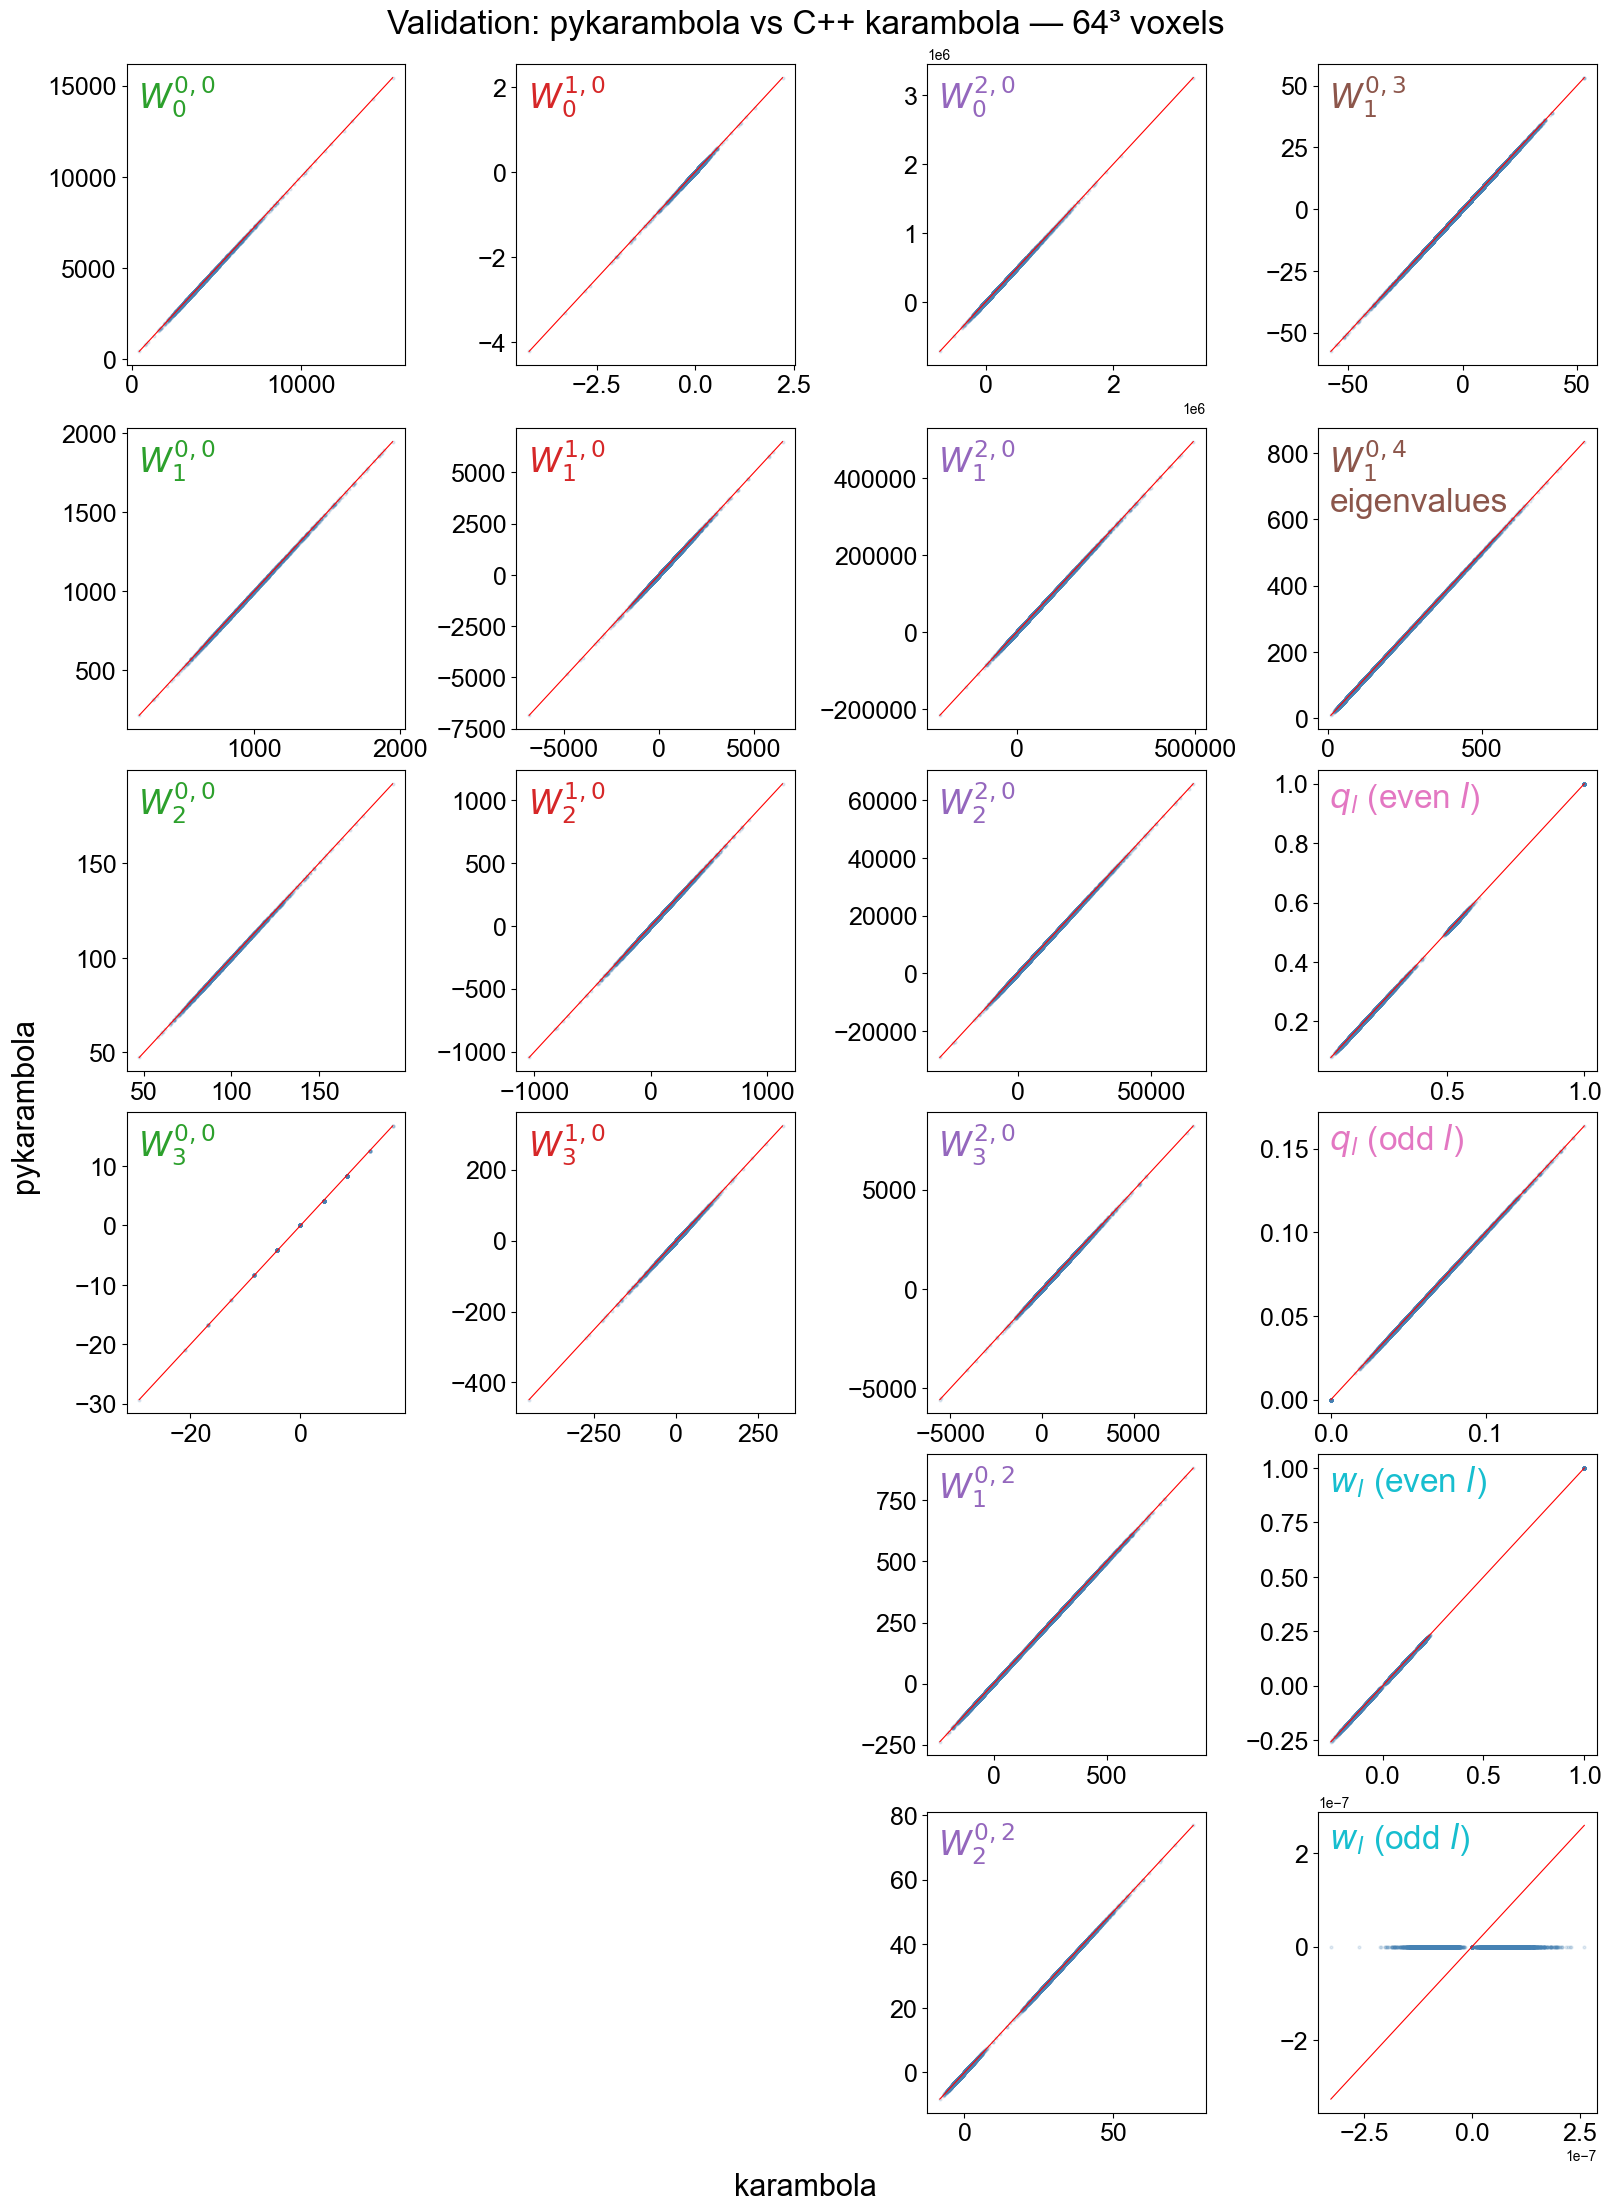

In [51]:
# ── Panel definitions — update w104 label to two lines ────────────────────────
panels_by_col = [
    # Column 1: Rank-0 scalars (4 panels)
    [
        (r'$W_0^{0,0}$', ['w000']),
        (r'$W_1^{0,0}$', ['w100']),
        (r'$W_2^{0,0}$', ['w200']),
        (r'$W_3^{0,0}$', ['w300']),
    ],
    # Column 2: Rank-1 vectors (4 panels)
    [
        (r'$W_0^{1,0}$', [f'w010_{i}' for i in range(3)]),
        (r'$W_1^{1,0}$', [f'w110_{i}' for i in range(3)]),
        (r'$W_2^{1,0}$', [f'w210_{i}' for i in range(3)]),
        (r'$W_3^{1,0}$', [f'w310_{i}' for i in range(3)]),
    ],
    # Column 3: Rank-2 tensors (6 panels)
    [
        (r'$W_0^{2,0}$', [f'w020_{i}{j}' for i in range(3) for j in range(3)]),
        (r'$W_1^{2,0}$', [f'w120_{i}{j}' for i in range(3) for j in range(3)]),
        (r'$W_2^{2,0}$', [f'w220_{i}{j}' for i in range(3) for j in range(3)]),
        (r'$W_3^{2,0}$', [f'w320_{i}{j}' for i in range(3) for j in range(3)]),
        (r'$W_1^{0,2}$', [f'w102_{i}{j}' for i in range(3) for j in range(3)]),
        (r'$W_2^{0,2}$', [f'w202_{i}{j}' for i in range(3) for j in range(3)]),
    ],
    # Column 4: Higher-rank + MSM (6 panels)
    [
        (r'$W_1^{0,3}$',                          [f'w103_{i}{j}{k}' for i in range(3) for j in range(3) for k in range(3)]),
        ('$W_1^{0,4}$\neigenvalues',              [f'w104_EVal{n}' for n in range(6)]),
        (r'$q_l$ (even $l$)',                     [f'msm_ql_{n}' for n in range(0, 9, 2)]),
        (r'$q_l$ (odd $l$)',                      [f'msm_ql_{n}' for n in range(1, 9, 2)]),
        (r'$w_l$ (even $l$)',                     [f'msm_wl_{n}' for n in range(0, 9, 2)]),
        (r'$w_l$ (odd $l$)',                      [f'msm_wl_{n}' for n in range(1, 9, 2)]),
    ],
]

# ── Colors per group ───────────────────────────────────────────────────────────
COL_COLORS = [
    '#2ca02c',  # column 1: scalars — green
    '#d62728',  # column 2: vectors — red
    '#9467bd',  # column 3: rank-2 — purple
]
COL4_COLORS = {
    0: '#8c564b',  # w103 — brown
    1: '#8c564b',  # w104 eigenvalues — brown
    2: '#e377c2',  # msm_ql even — pink
    3: '#e377c2',  # msm_ql odd — pink
    4: '#17becf',  # msm_wl even — teal
    5: '#17becf',  # msm_wl odd — teal
}

BASE_FONT = 22
plt.rcParams['font.family'] = 'Arial'

def make_figure(channel, save_path):
    fig, axes = plt.subplots(6, 4, figsize=(16, 22), constrained_layout=True)

    for row in [4, 5]:
        axes[row, 0].set_visible(False)
        axes[row, 1].set_visible(False)

    for col, col_panels in enumerate(panels_by_col):
        for row, (label, features) in enumerate(col_panels):
            ax = axes[row, col]
            df_m = merged[channel]

            if col < 3:
                label_color = COL_COLORS[col]
            else:
                label_color = COL4_COLORS[row]

            k_all, py_all = [], []
            for feat in features:
                if f'{feat}_k' not in df_m.columns or f'{feat}_py' not in df_m.columns:
                    continue
                k_vals  = df_m[f'{feat}_k'].dropna()
                py_vals = df_m[f'{feat}_py'].dropna()
                common  = k_vals.index.intersection(py_vals.index)
                k_all.append(k_vals.loc[common].values)
                py_all.append(py_vals.loc[common].values)

            if k_all:
                k_all  = np.concatenate(k_all)
                py_all = np.concatenate(py_all)
                ax.scatter(k_all, py_all, s=4, alpha=0.15, rasterized=True, color='steelblue')
                lo = min(k_all.min(), py_all.min())
                hi = max(k_all.max(), py_all.max())
                ax.plot([lo, hi], [lo, hi], 'r-', lw=0.8, zorder=5)

            ax.tick_params(labelsize=BASE_FONT - 4)

            # tensor label only — no alphabet
            ax.text(
                0.04, 0.97, label,
                transform=ax.transAxes,
                fontsize=BASE_FONT + 2, color=label_color,
                va='top', ha='left', 
            )

    fig.supxlabel('karambola', fontsize=BASE_FONT)
    fig.supylabel('pykarambola', fontsize=BASE_FONT)
    fig.suptitle(
        f'Validation: pykarambola vs C++ karambola — {channel}³ voxels',
        fontsize=BASE_FONT + 2,
    )
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {save_path}')
    plt.show()

make_figure('28', os.path.join(FIGURES_PATH, 'scatter_accuracy_paper.pdf'))
make_figure('64', os.path.join(FIGURES_PATH, 'scatter_accuracy_paper_supplementary.pdf'))

  Saved → results/scatter_scalars_vectors_28.pdf


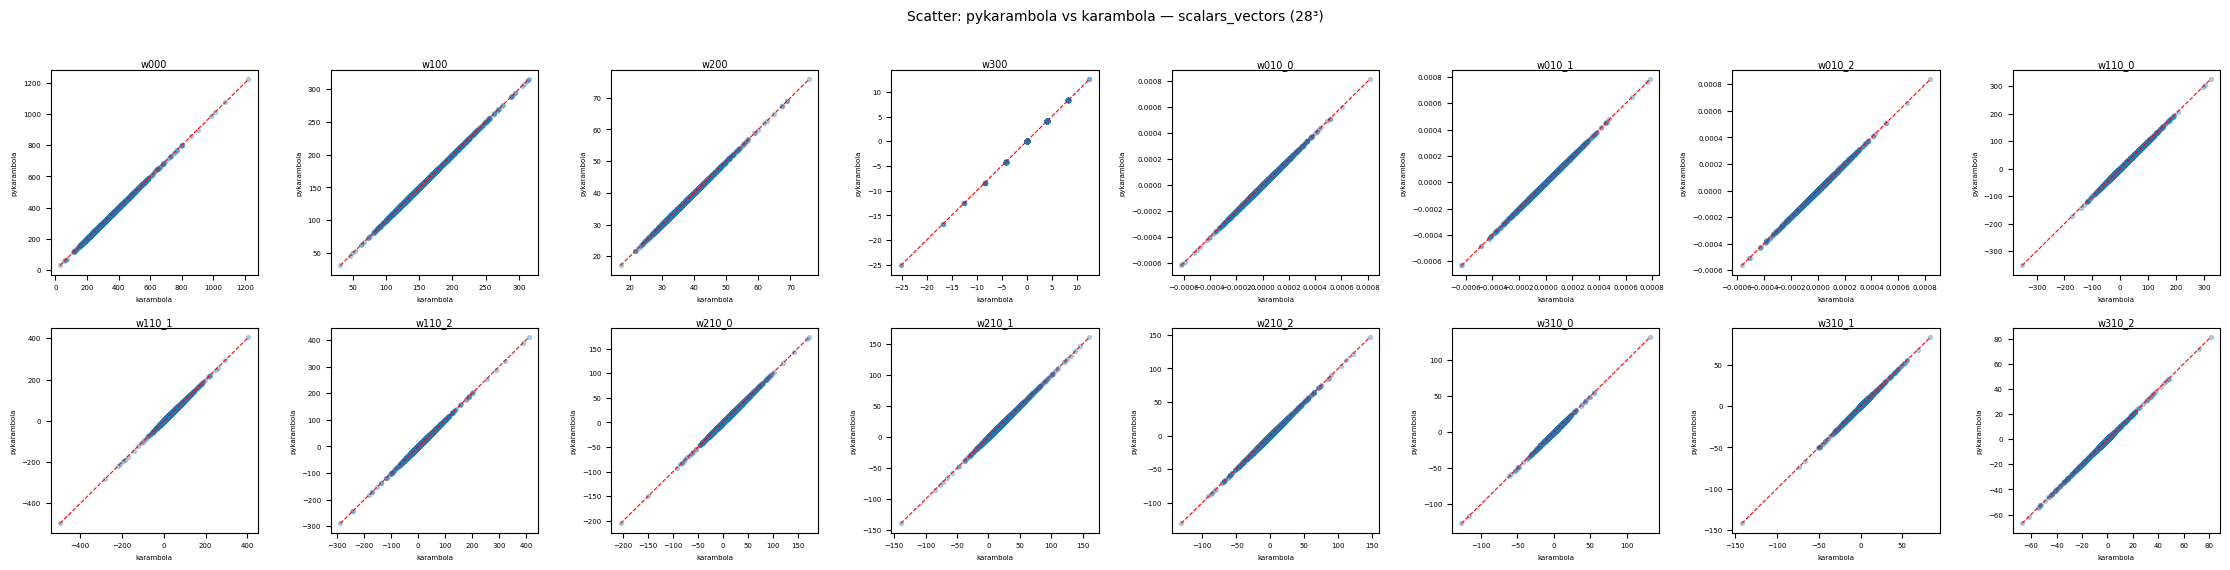

  Saved → results/scatter_rank2_tensors_28.pdf


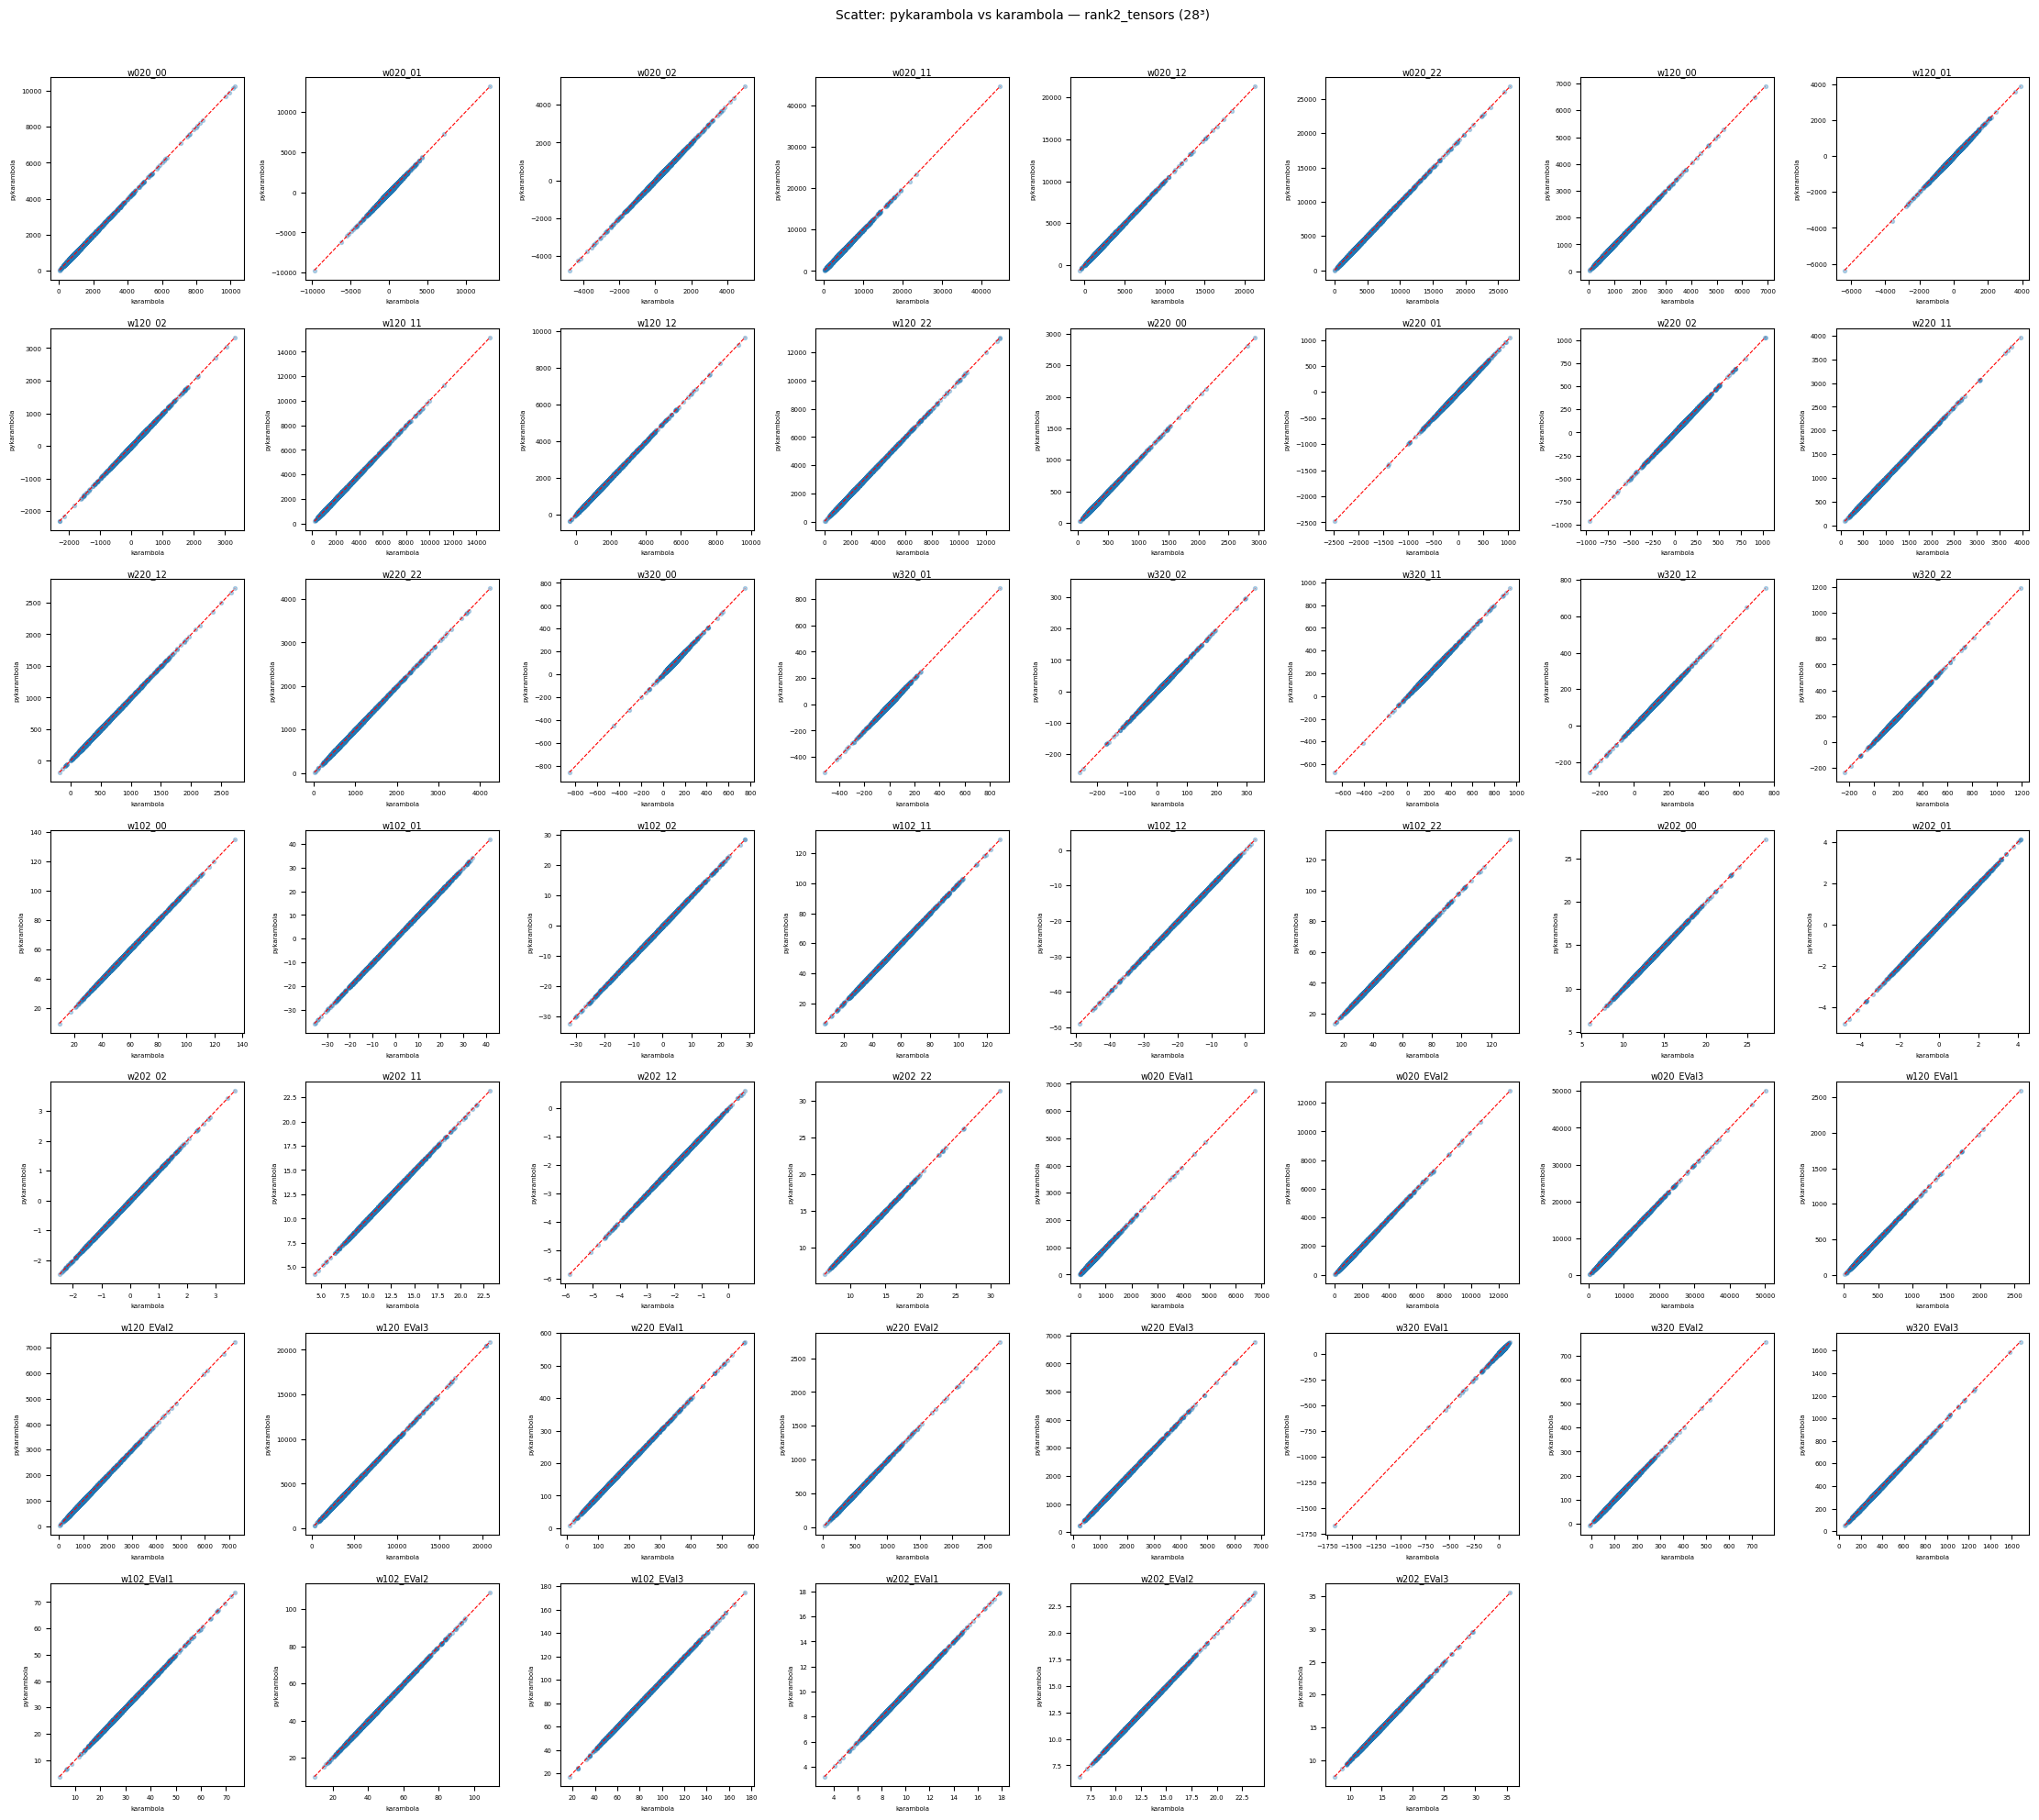

  Saved → results/scatter_w103_28.pdf


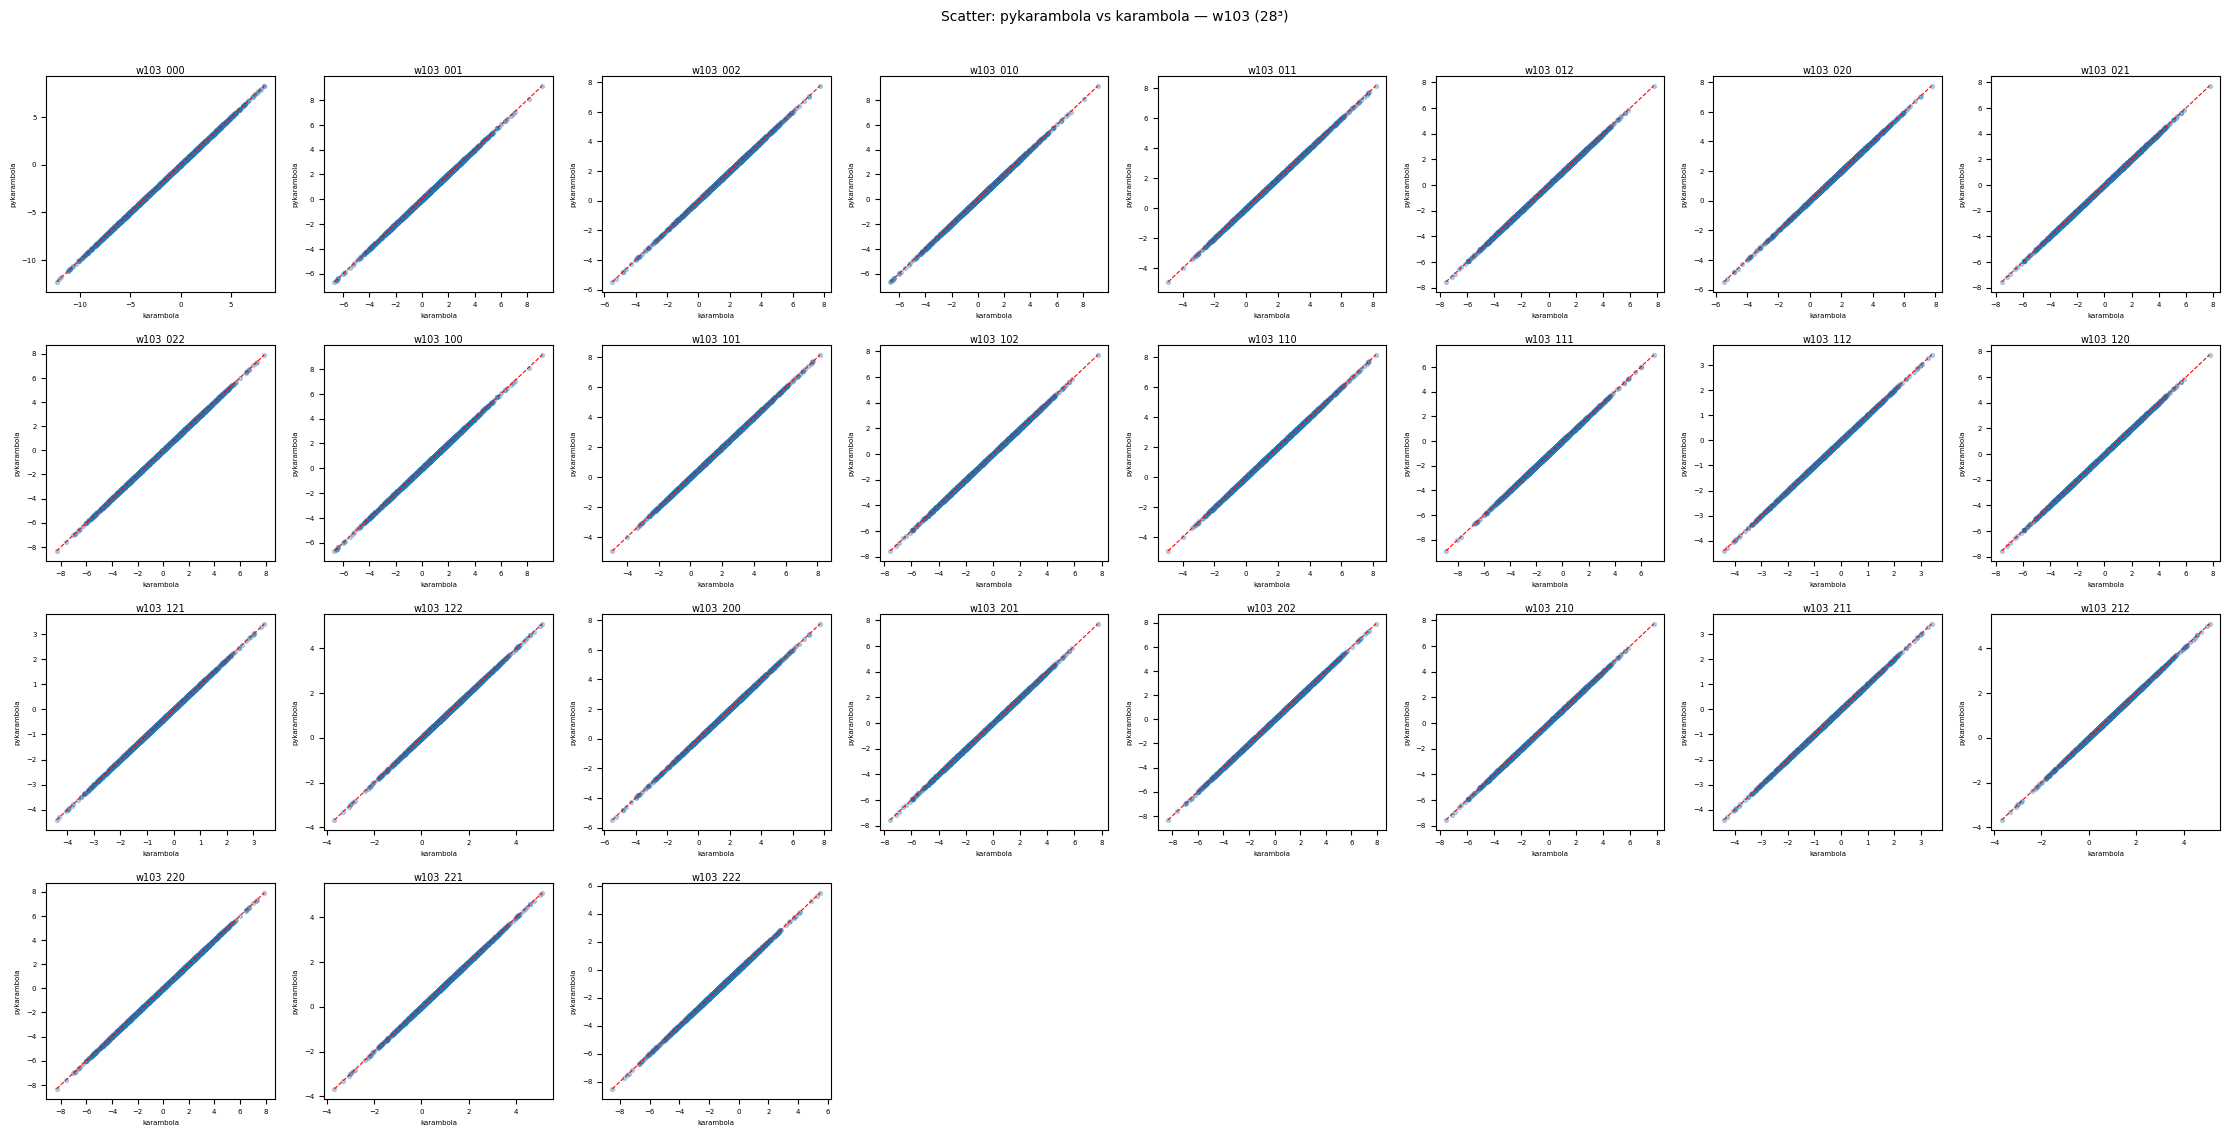

  Saved → results/scatter_w104_msm_28.pdf


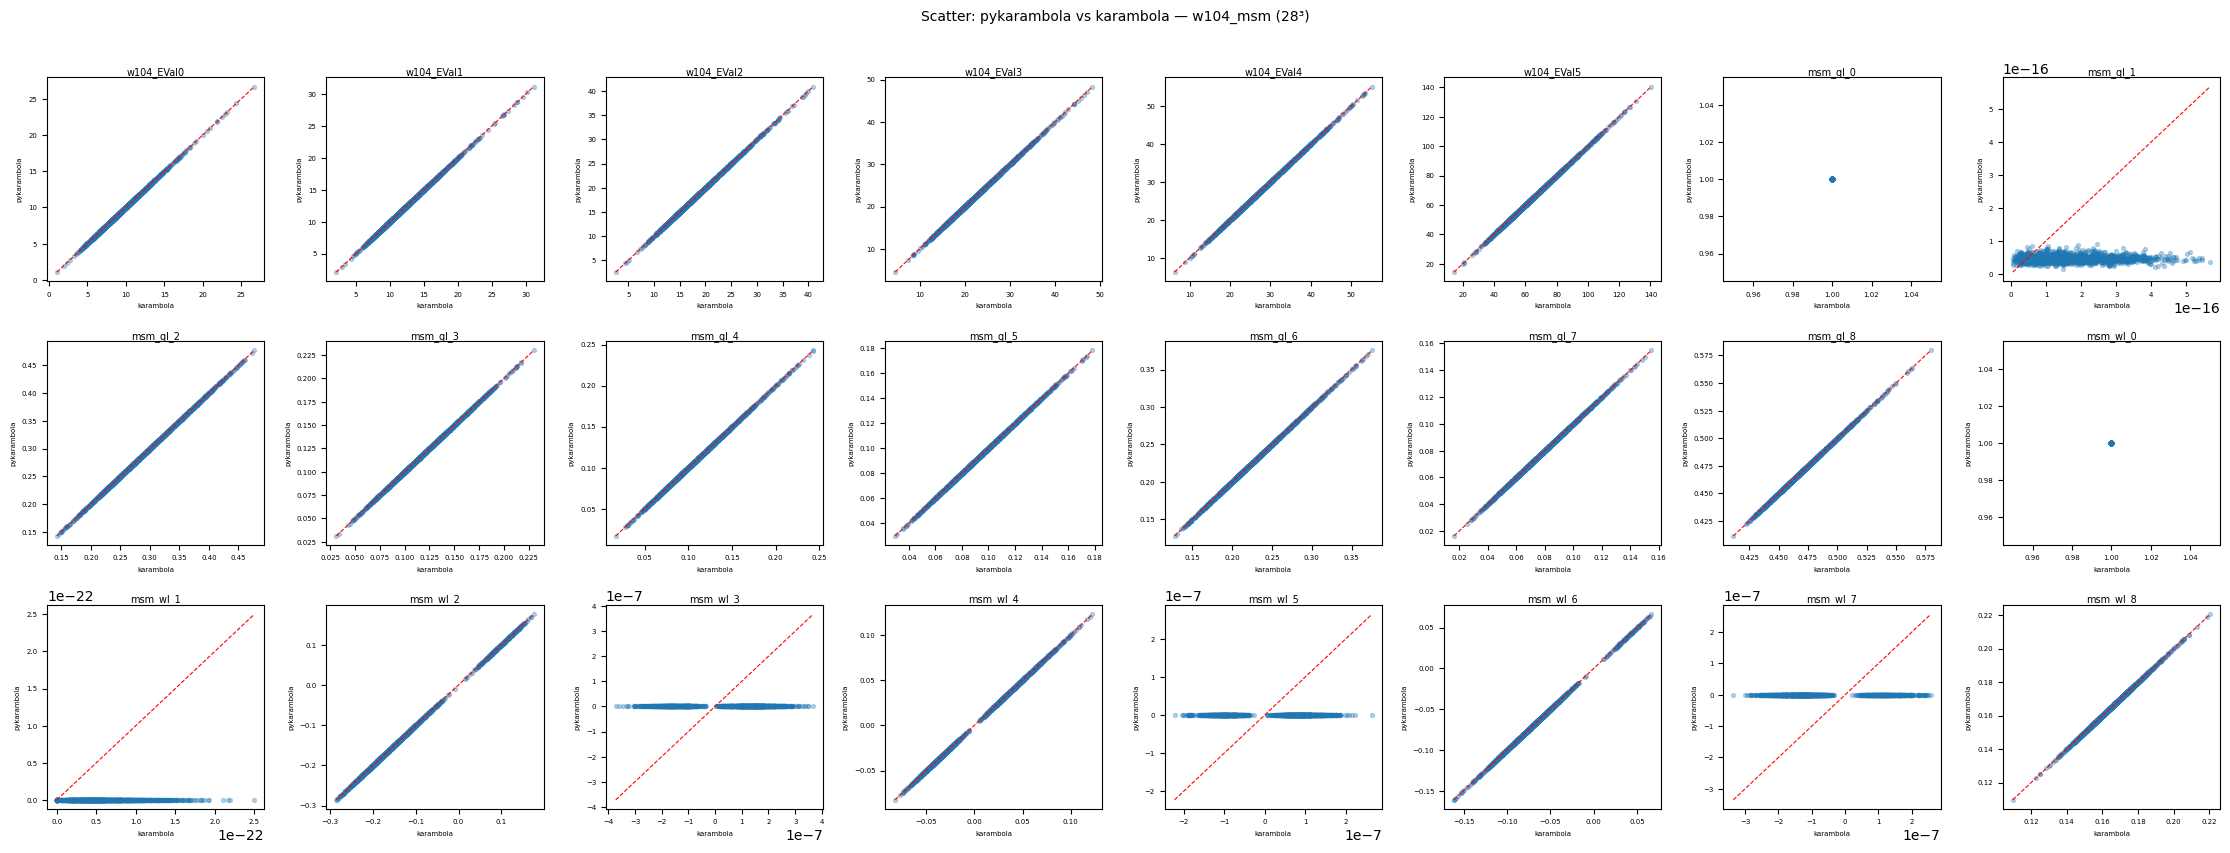

  Saved → results/scatter_scalars_vectors_64.pdf


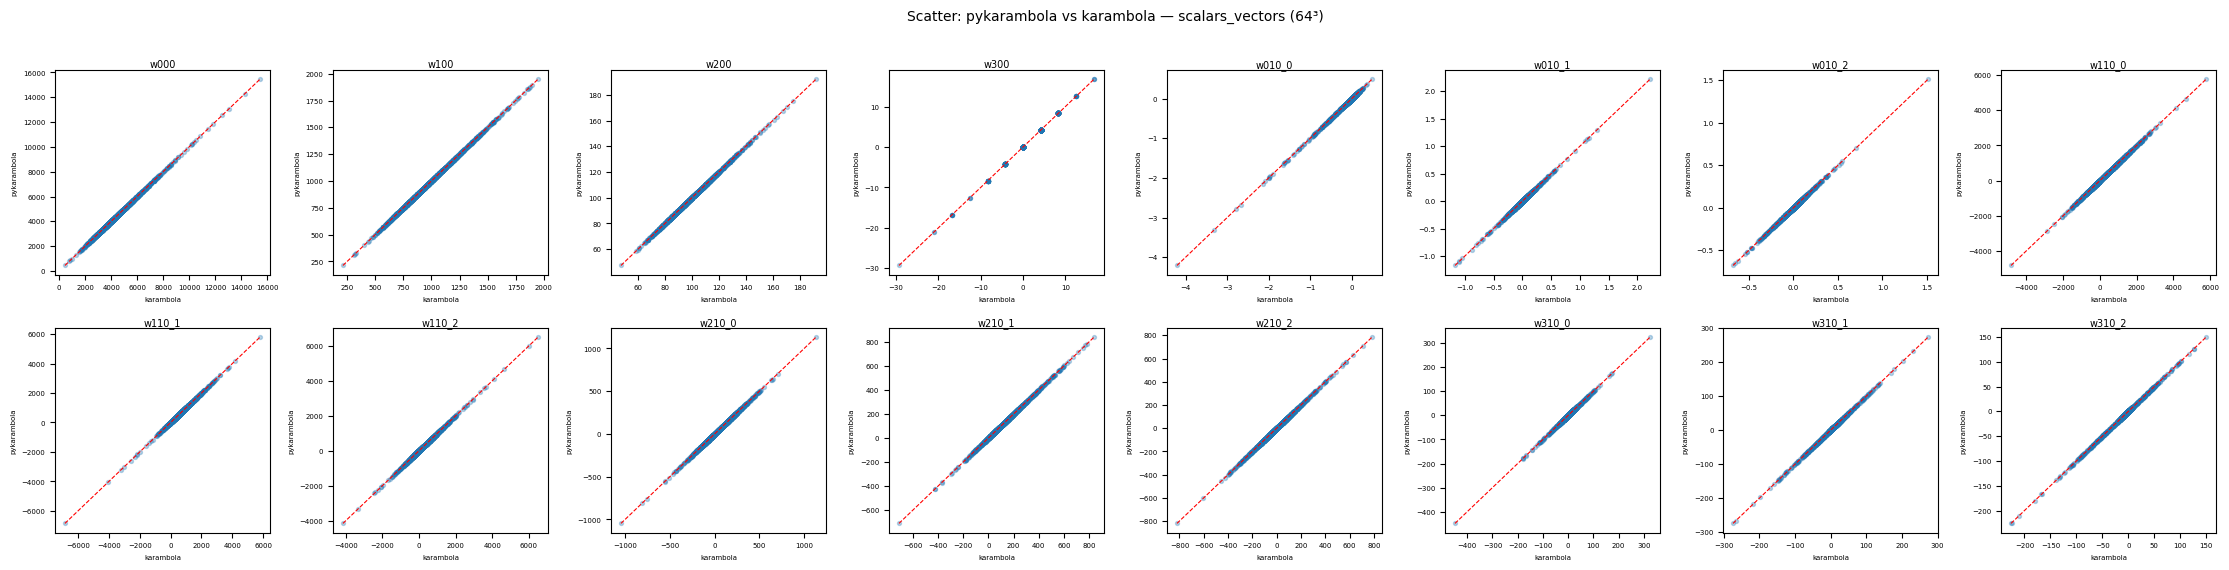

  Saved → results/scatter_rank2_tensors_64.pdf


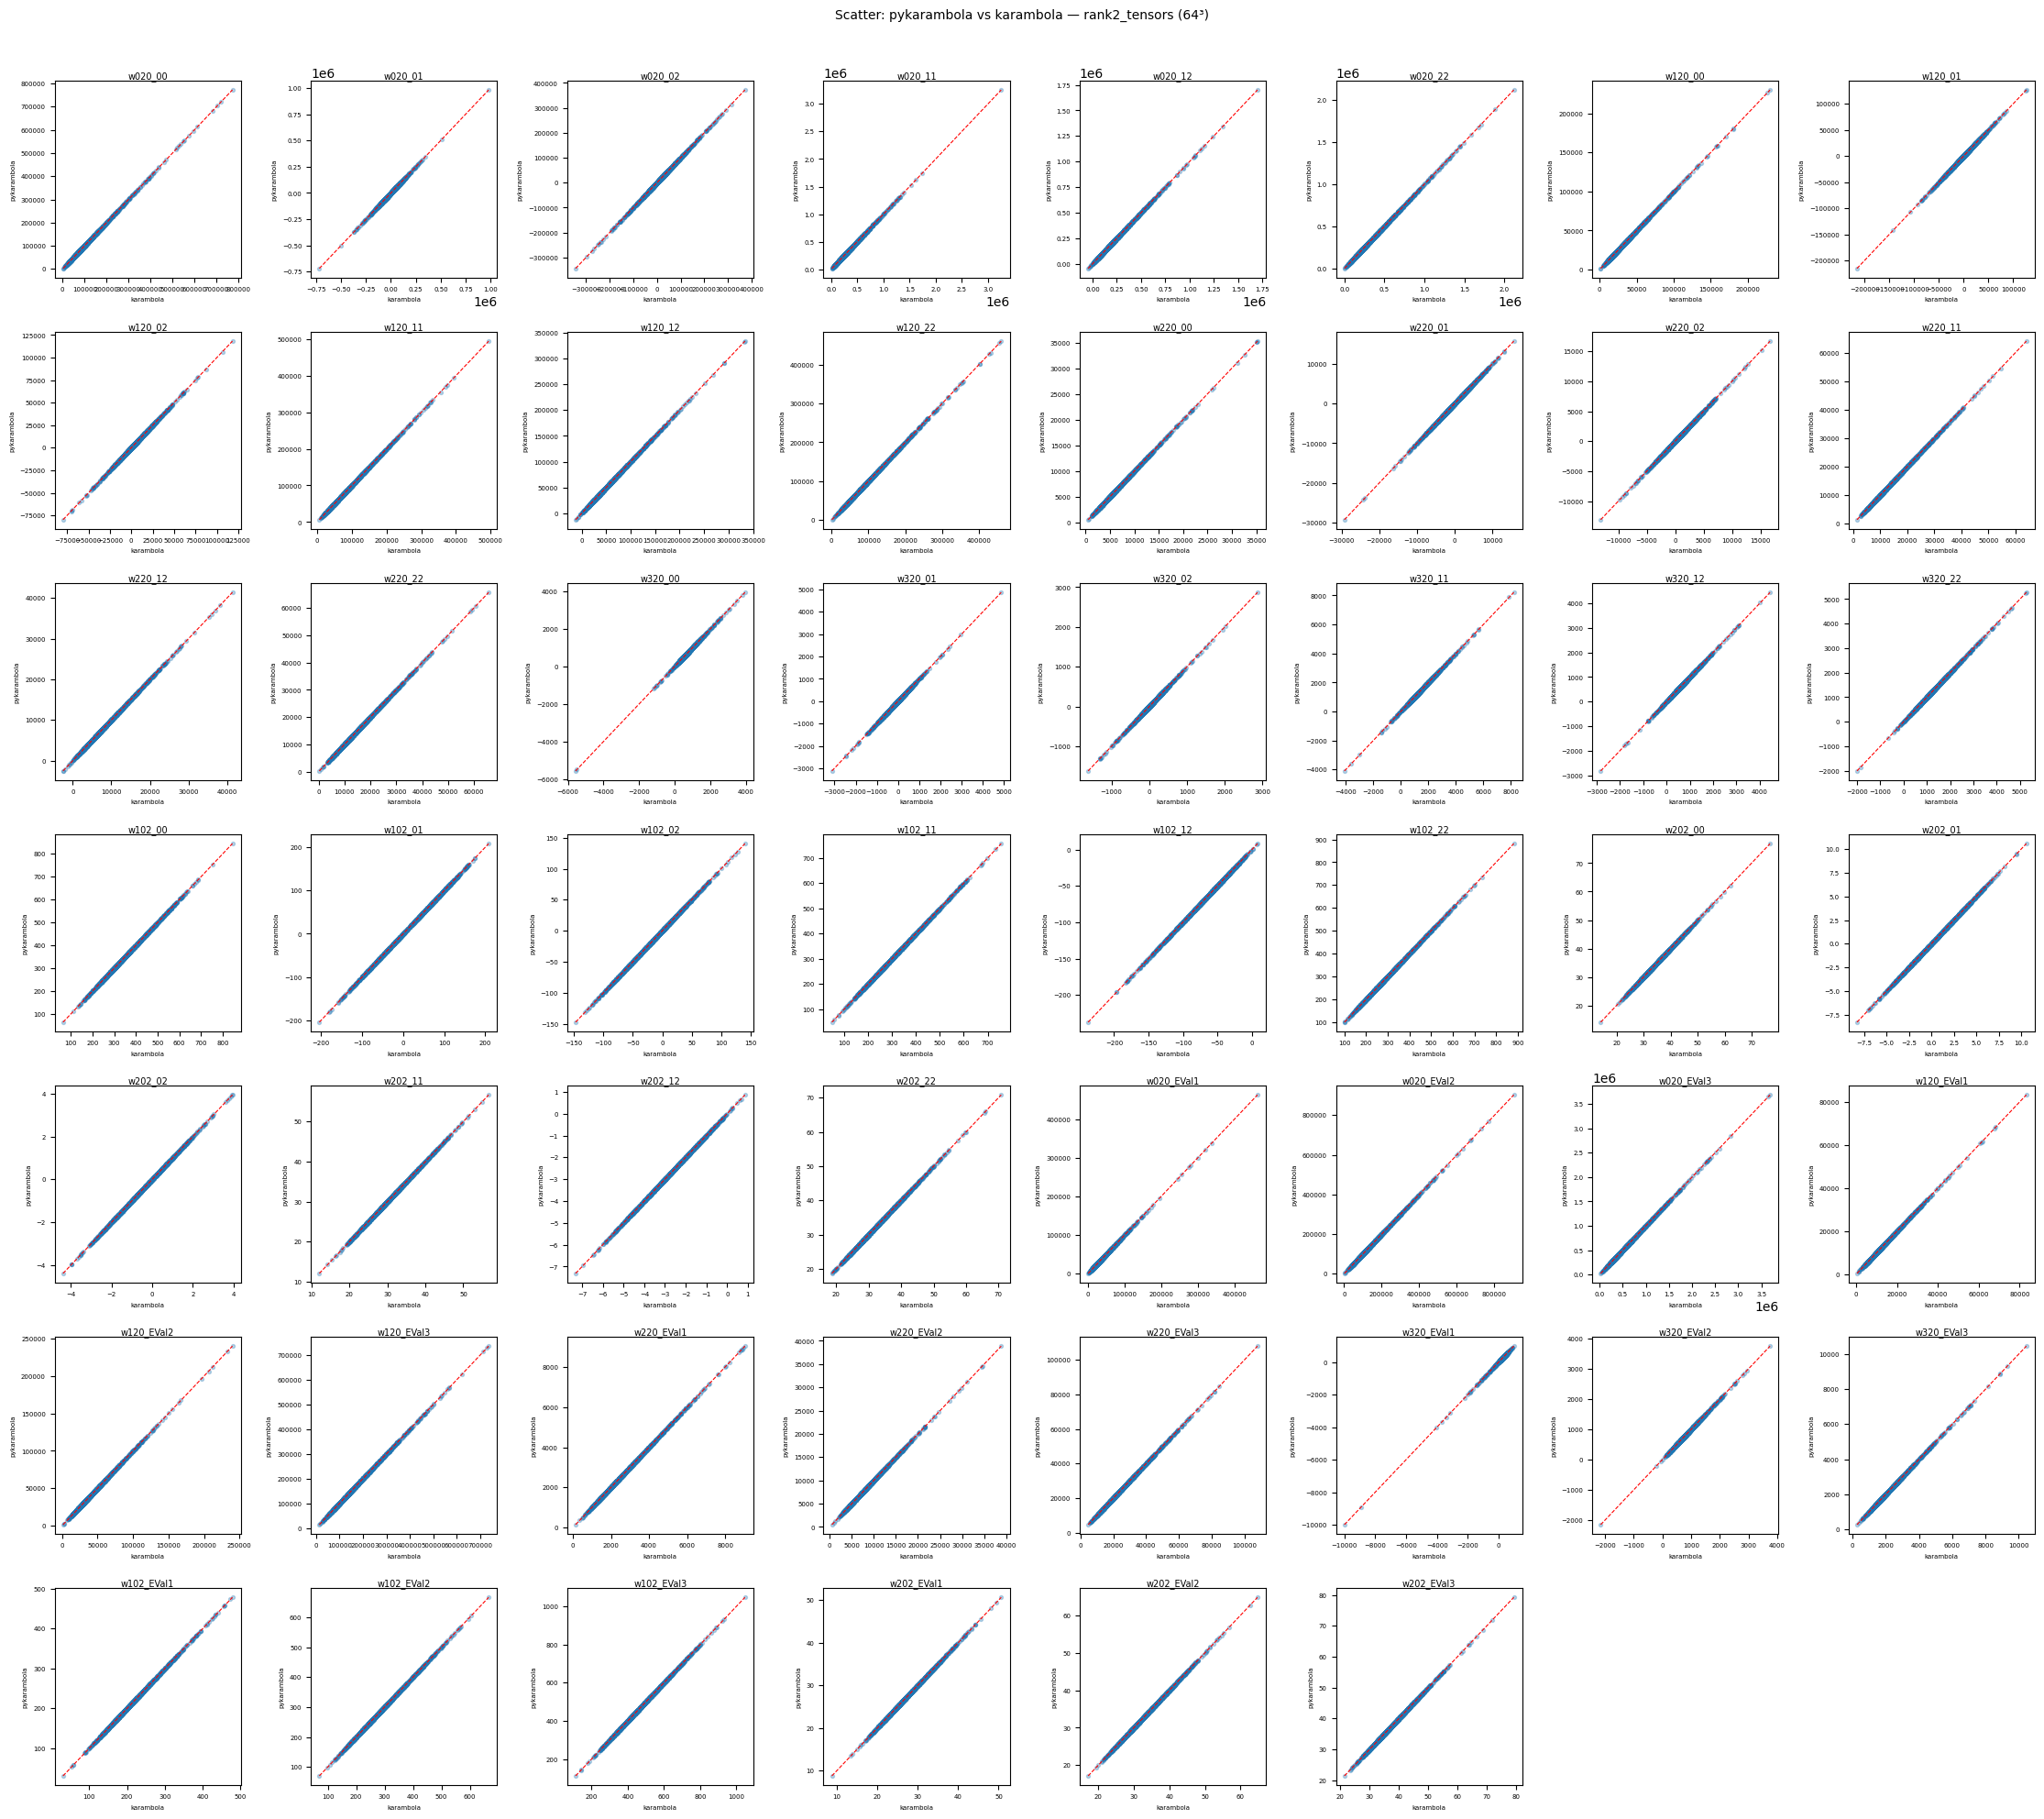

  Saved → results/scatter_w103_64.pdf


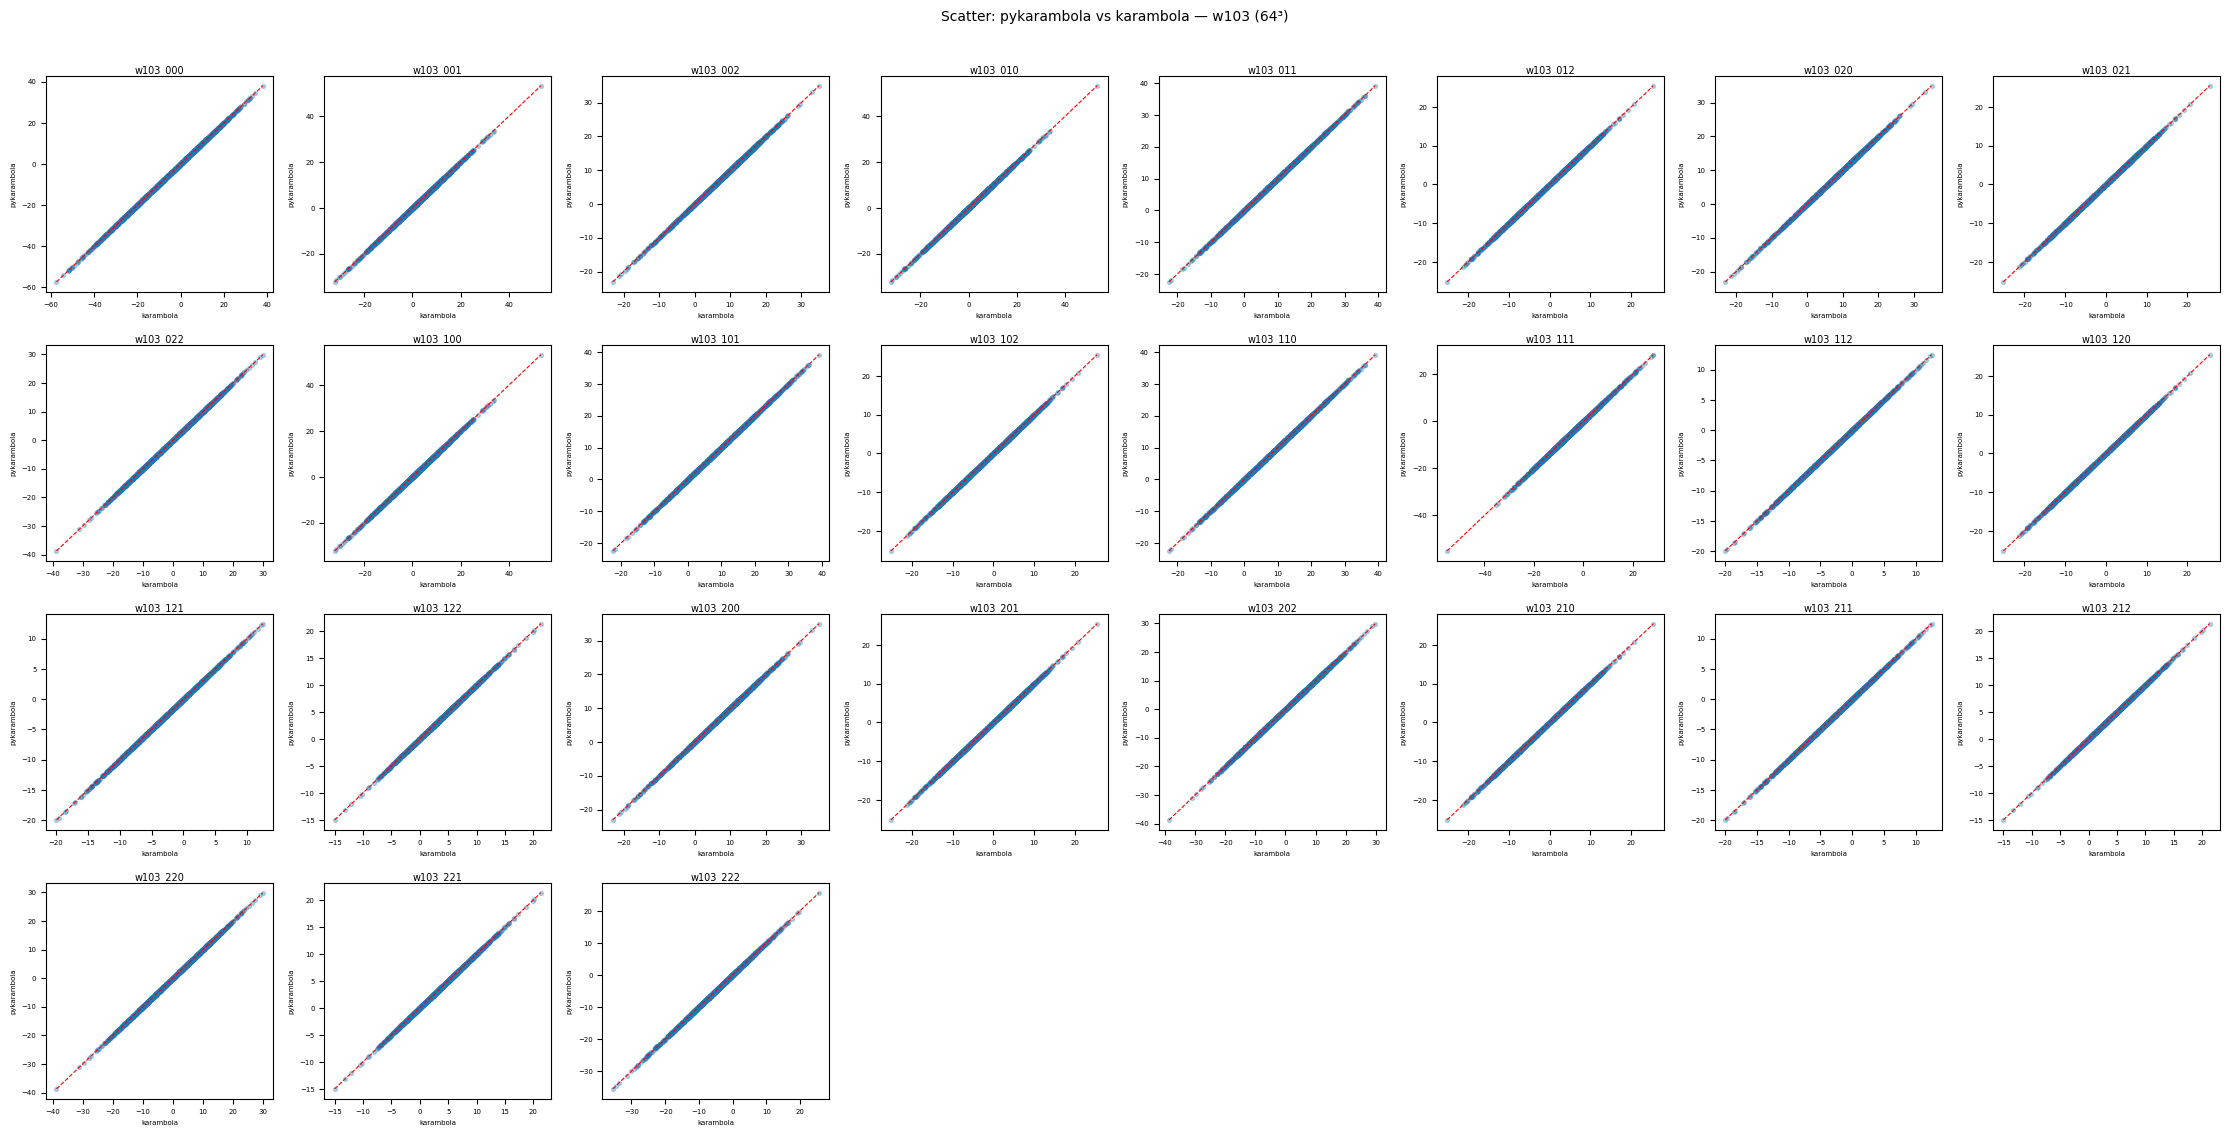

  Saved → results/scatter_w104_msm_64.pdf


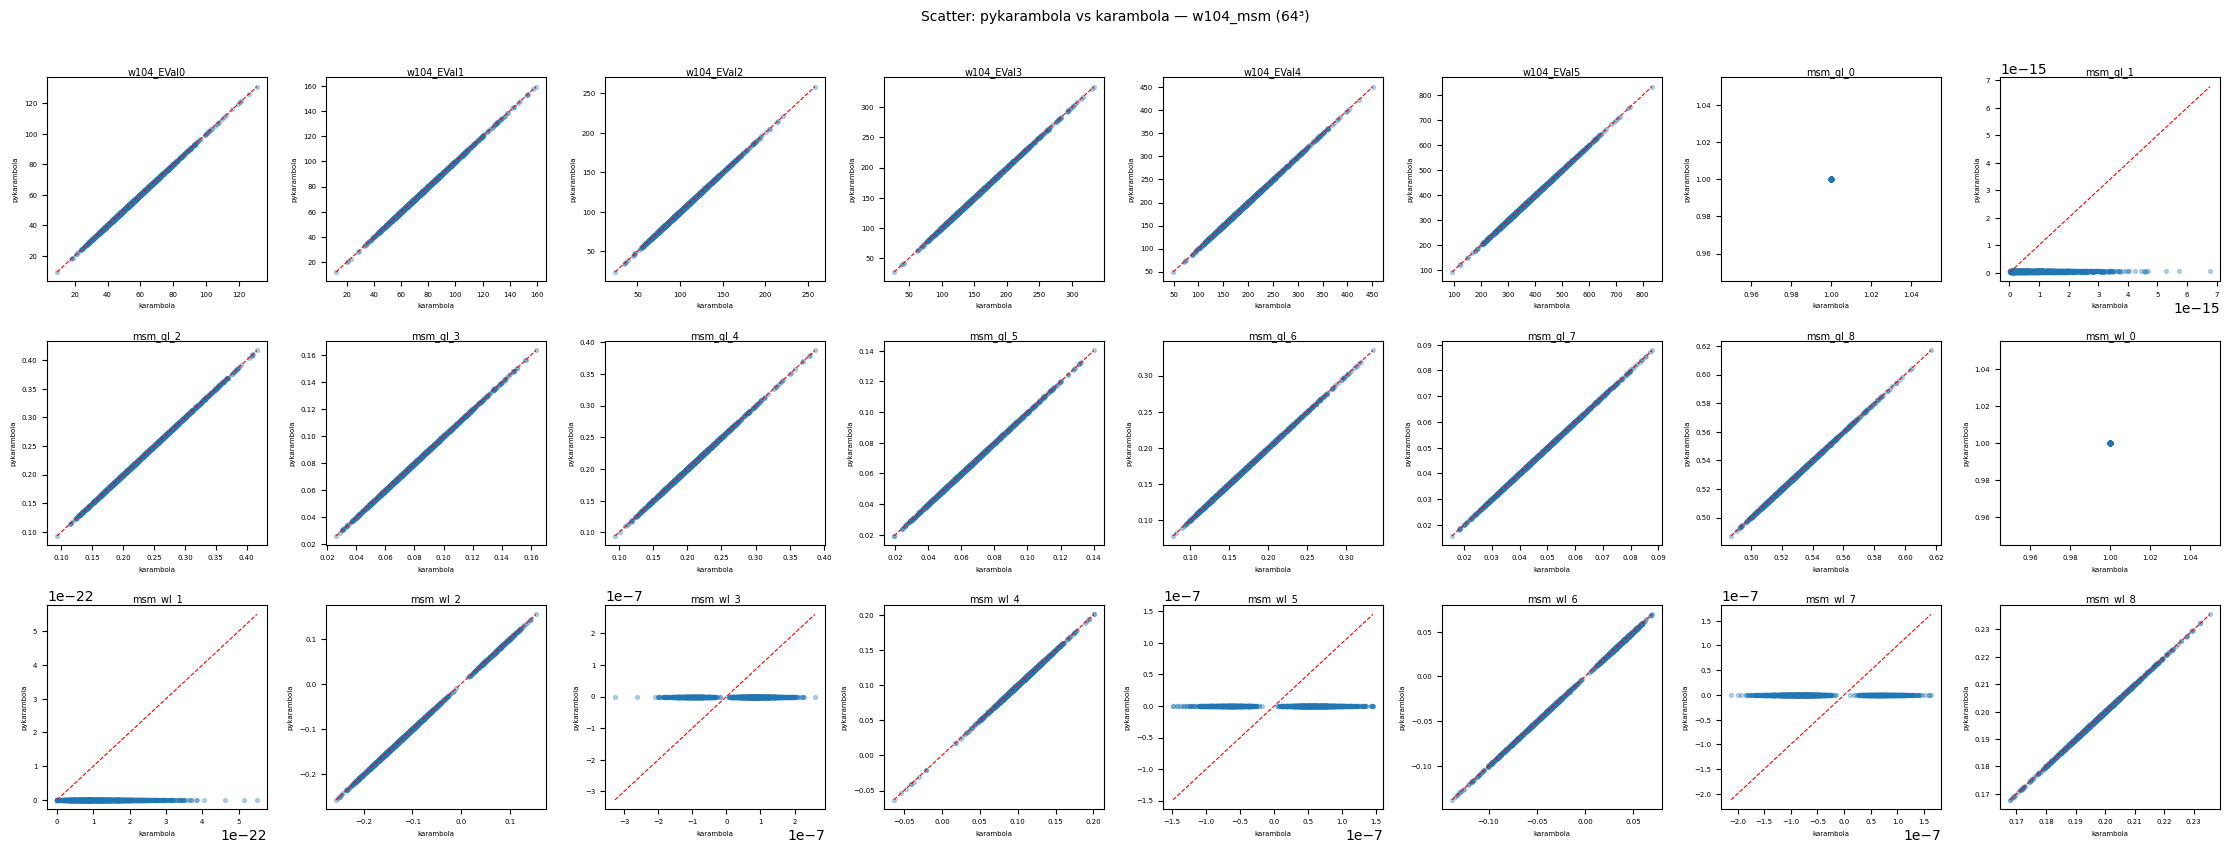

In [20]:
# ── Feature groups ───────────────────────────────────────────────────────
feat_groups = {
    'scalars_vectors': (
        SCALAR_KEYS
        + [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
    ),
    'rank2_tensors': (
        [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
        + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
    ),
    'w103': [f'w103_{i}{j}{k}' for i in range(3) for j in range(3) for k in range(3)],
    'w104_msm': (
        [f'w104_EVal{n}' for n in range(6)]
        + [f'msm_ql_{n}' for n in range(9)]
        + [f'msm_wl_{n}' for n in range(9)]
    ),
}

GROUP_LABELS = {
    'scalars_vectors': 'Scalars & vectors',
    'rank2_tensors':   'Rank-2 tensors',
    'w103':            'w103',
    'w104_msm':        'w104 & MSM',
}


# ── Diagnostic: per-feature scatter grids ────────────────────────────────────
def scatter_group(df_m, features, title, fig_path, ncols=8):
    valid = [f for f in features if f'{f}_k' in df_m.columns and f'{f}_py' in df_m.columns]
    if not valid:
        print(f'  [skip] no valid columns for: {title}')
        return
    nrows = int(np.ceil(len(valid) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.8))
    axes = np.array(axes).flatten()
    for idx, feat in enumerate(valid):
        ax = axes[idx]
        k_vals  = df_m[f'{feat}_k'].dropna()
        py_vals = df_m[f'{feat}_py'].dropna()
        common  = k_vals.index.intersection(py_vals.index)
        k_vals, py_vals = k_vals.loc[common], py_vals.loc[common]
        if len(k_vals) == 0:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=7, color='grey')
        else:
            ax.scatter(k_vals, py_vals, s=8, alpha=0.3, rasterized=True)
            lo = min(k_vals.min(), py_vals.min())
            hi = max(k_vals.max(), py_vals.max())
            ax.plot([lo, hi], [lo, hi], 'r--', lw=0.8)
        ax.set_title(feat, fontsize=7, pad=2)
        ax.tick_params(labelsize=5)
        ax.set_xlabel('karambola', fontsize=5)
        ax.set_ylabel('pykarambola', fontsize=5)
    for idx in range(len(valid), len(axes)):
        axes[idx].set_visible(False)
    fig.suptitle(title, fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'  Saved → {fig_path}')
    plt.show()

for channel in CHANNELS:
    df_m = merged[channel]
    for group_name, features in feat_groups.items():
        title    = f'Scatter: pykarambola vs karambola — {group_name} ({channel}³)'
        fig_path = os.path.join(FIGURES_PATH, f'scatter_{group_name}_{channel}.pdf')
        scatter_group(df_m, features, title, fig_path)


### Figure 2 — Bar chart: max absolute difference per feature (diagnostic)

  28³ worst: w220_EVal3  max_abs_diff=4.28e-05  max_val=6.78e+03  ratio=6.31e-09
  64³ worst: w220_EVal3  max_abs_diff=1.74e-03  max_val=1.08e+05  ratio=1.61e-08
Saved → results/bar_abs_diff.pdf


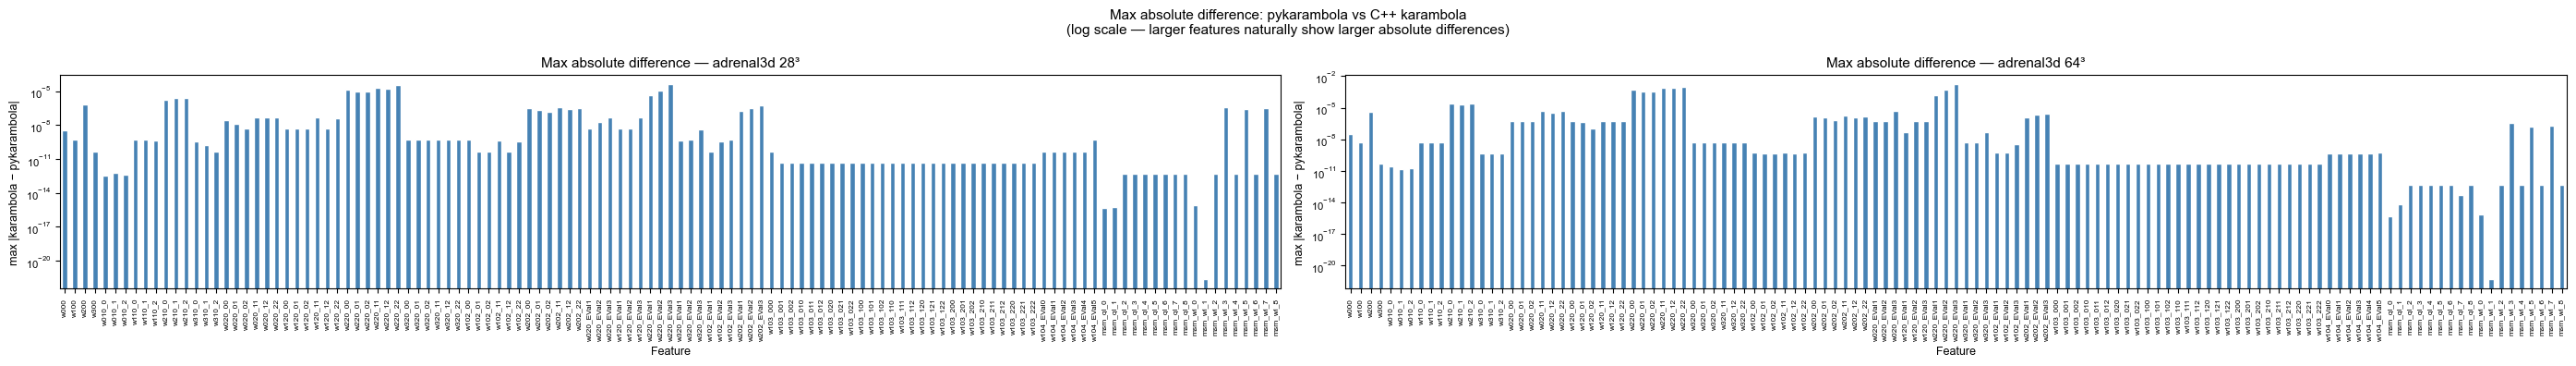

In [33]:
# Standard-only cols — for cells that load old karambola/pykarambola CSVs directly
STANDARD_COMPARE_COLS = (
    SCALAR_KEYS
    + [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
    + [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
    + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
)

# Full compare cols including higher-rank — used with merged[channel]
compare_cols = (
    SCALAR_KEYS
    + [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
    + [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
    + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
    + [f'w103_{i}{j}{k}' for i in range(3) for j in range(3) for k in range(3)]
    + [f'w104_EVal{n}' for n in range(6)]
    + [f'msm_ql_{n}' for n in range(9)]
    + [f'msm_wl_{n}' for n in range(9)]
)

# Absolute difference per feature (log scale).
# Features with large values (e.g. w220) show larger absolute differences —
# this is expected: the differences scale with the feature magnitude.
# Near-zero features (e.g. msm_wl) show tiny absolute differences.
fig, axes = plt.subplots(1, 2, figsize=(28, 4), sharey=False)

for ax, channel in zip(axes, CHANNELS):
    df_m    = merged[channel]
    summary = abs_diff_summary(df_m, compare_cols)

    summary['max_abs_diff'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_yscale('log')
    ax.set_title(f'Max absolute difference — adrenal3d {channel}³', fontsize=11)
    ax.set_xlabel('Feature', fontsize=9)
    ax.set_ylabel('max |karambola − pykarambola|', fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.tick_params(axis='y', labelsize=8)

    worst = summary['max_abs_diff'].idxmax()
    worst_val = summary.loc[worst, 'max_abs_diff']
    worst_scale = summary.loc[worst, 'max_val']
    print(f'  {channel}³ worst: {worst}  max_abs_diff={worst_val:.2e}  '
          f'max_val={worst_scale:.2e}  ratio={worst_val/worst_scale:.2e}')

plt.suptitle(
    'Max absolute difference: pykarambola vs C++ karambola\n'
    '(log scale — larger features naturally show larger absolute differences)',
    fontsize=11,
)
plt.tight_layout()
fig_path = os.path.join(FIGURES_PATH, 'bar_abs_diff.pdf')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved → {fig_path}')
plt.show()


### Table — max and mean absolute difference per feature

In [34]:
for channel in CHANNELS:
    df_m    = merged[channel]
    summary = abs_diff_summary(df_m, compare_cols)
    print(f'\n=== adrenal3d_{channel} ===')
    print(summary.to_string(float_format='{:.3e}'.format))
    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_abs_diff_summary.csv')
    summary.to_csv(csv_path)
    print(f'Saved → {csv_path}')



=== adrenal3d_28 ===
            max_abs_diff  mean_abs_diff   max_val
feature                                          
w000           3.334e-09      2.269e-10 1.223e+03
w100           5.009e-10      2.440e-10 3.151e+02
w200           7.311e-07      2.551e-07 7.577e+01
w300           4.558e-11      3.336e-12 2.513e+01
w010_0         3.477e-13      3.122e-14 8.146e-04
w010_1         5.607e-13      4.147e-14 7.825e-04
w010_2         4.547e-13      3.284e-14 8.375e-04
w110_0         4.945e-10      3.924e-11 3.520e+02
w110_1         4.998e-10      3.876e-11 4.977e+02
w110_2         4.802e-10      2.866e-11 4.102e+02
w210_0         1.663e-06      2.039e-07 2.054e+02
w210_1         2.637e-06      3.695e-07 1.607e+02
w210_2         2.713e-06      3.835e-07 1.465e+02
w310_0         3.818e-10      6.911e-12 1.319e+02
w310_1         1.586e-10      7.094e-12 1.419e+02
w310_2         4.990e-11      6.095e-12 8.113e+01
w020_00        2.943e-08      1.561e-09 1.026e+04
w020_01        1.268e-08    

### Figure 3 — Heatmap: mean absolute difference per label × feature

Saved → results/heatmap_scalars_vectors.pdf


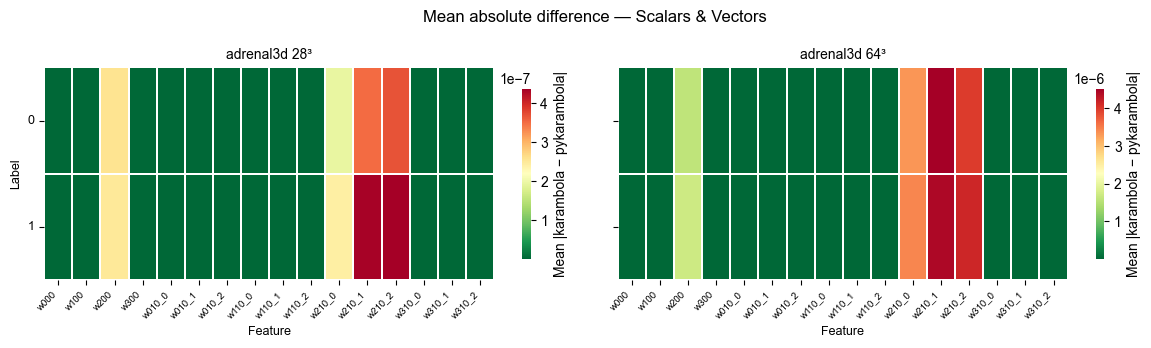

Saved → results/heatmap_rank2_tensors.pdf


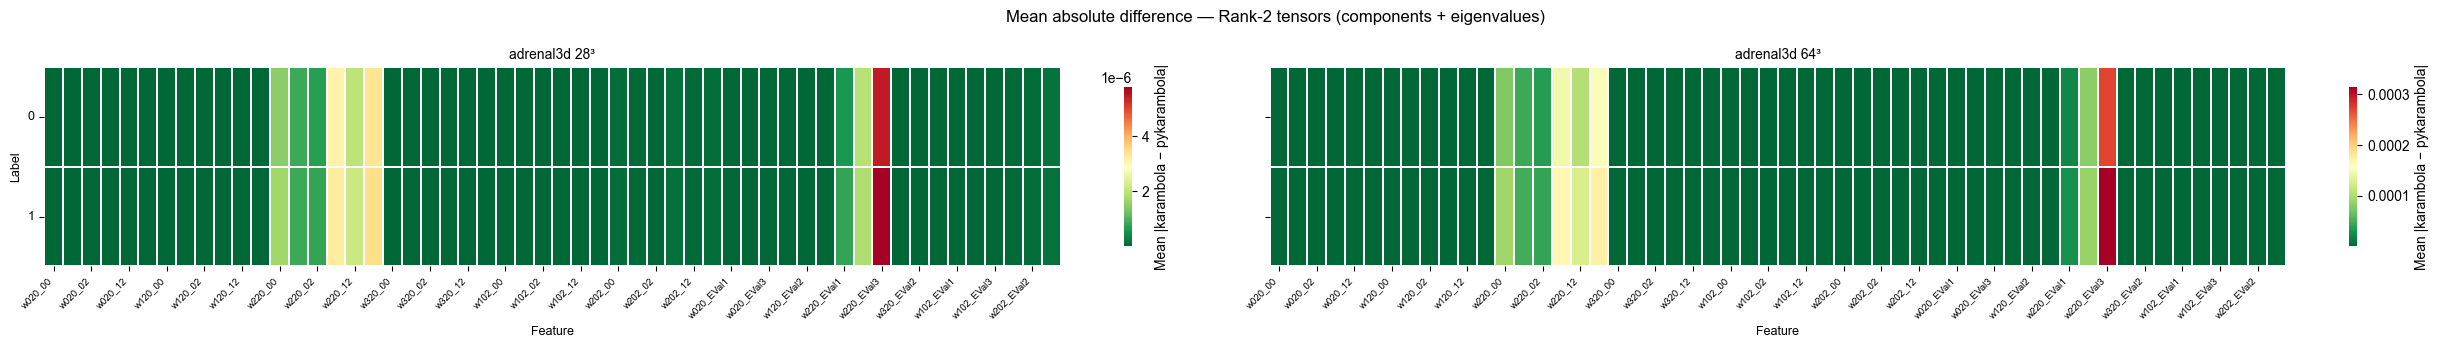

Saved → results/heatmap_higher_rank.pdf


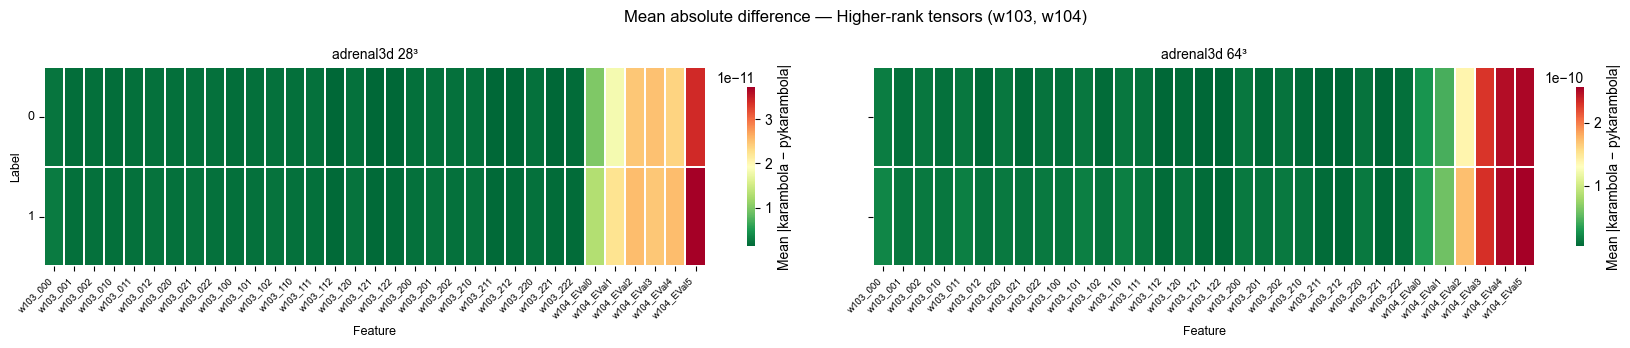

Saved → results/heatmap_msm.pdf


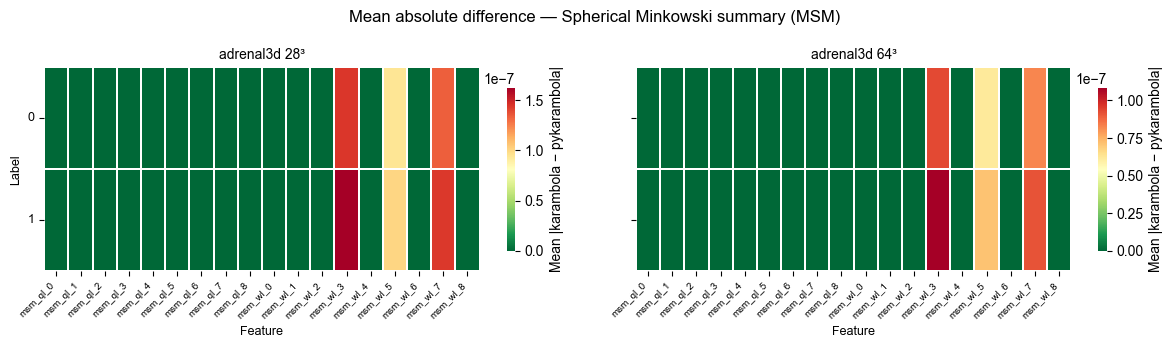

In [35]:
# ── Feature slices for the four heatmap figures ────────────────────────────
_scalar_cols = SCALAR_KEYS
_vector_cols  = [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
_tensor_cols  = (
    [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
    + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
)
_w103_cols = [f'w103_{i}{j}{k}' for i in range(3) for j in range(3) for k in range(3)]
_w104_cols = [f'w104_EVal{n}' for n in range(6)]
_msm_cols  = [f'msm_ql_{n}' for n in range(9)] + [f'msm_wl_{n}' for n in range(9)]

_heatmap_groups = [
    ('scalars_vectors',   'Scalars & Vectors',                   _scalar_cols + _vector_cols),
    ('rank2_tensors',     'Rank-2 tensors (components + eigenvalues)', _tensor_cols),
    ('higher_rank',       'Higher-rank tensors (w103, w104)',     _w103_cols + _w104_cols),
    ('msm',               'Spherical Minkowski summary (MSM)',    _msm_cols),
]

for slug, group_title, group_cols in _heatmap_groups:
    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(12, len(group_cols) * 0.4 + 4), 3.5),
        sharey=True,
    )
    for ax, channel in zip(axes, CHANNELS):
        df_m  = merged[channel]
        avail = [c for c in group_cols if f'{c}_k' in df_m.columns]

        heatmap_rows = []
        for lbl in sorted(df_m['label'].unique()):
            mask = df_m['label'] == lbl
            row  = {'label': lbl}
            for col in avail:
                diff = (df_m.loc[mask, f'{col}_k'] - df_m.loc[mask, f'{col}_py']).abs()
                row[col] = diff.mean()
            heatmap_rows.append(row)

        hmap_df = pd.DataFrame(heatmap_rows).set_index('label')[avail].fillna(0)

        seaborn.heatmap(
            hmap_df, annot=False, cmap='RdYlGn_r', linewidths=0.2, ax=ax,
            cbar_kws={'label': 'Mean |karambola − pykarambola|', 'shrink': 0.8},
        )
        ax.set_title(f'adrenal3d {channel}³', fontsize=10)
        ax.set_xlabel('Feature', fontsize=9)
        ax.set_ylabel('Label' if channel == CHANNELS[0] else '', fontsize=9)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=9)

    fig.suptitle(f'Mean absolute difference — {group_title}', fontsize=12)
    plt.tight_layout()
    fig_path = os.path.join(FIGURES_PATH, f'heatmap_{slug}.pdf')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {fig_path}')
    plt.show()


### Figure 4 — Heatmap: relative error per label × feature

Saved → results/heatmap_rel_scalars_vectors.pdf


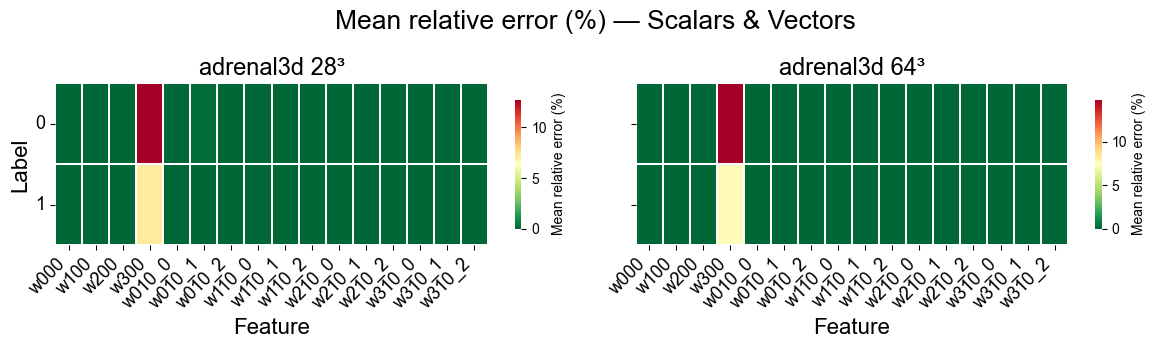

Saved → results/heatmap_rel_rank2_tensors.pdf


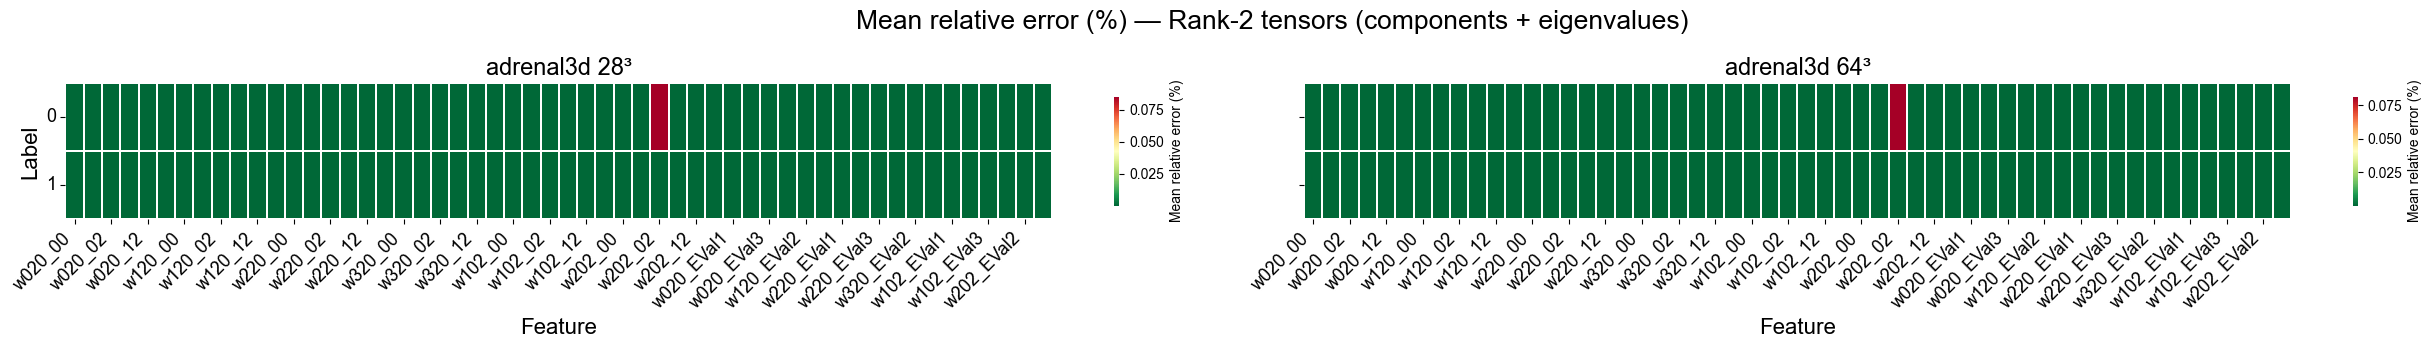

Saved → results/heatmap_rel_higher_rank.pdf


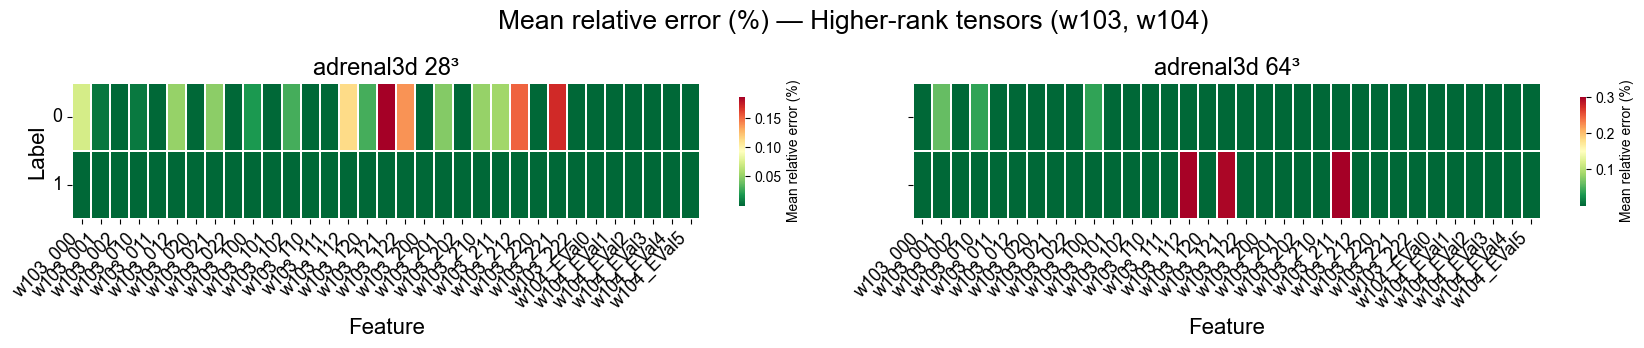

Saved → results/heatmap_rel_msm.pdf


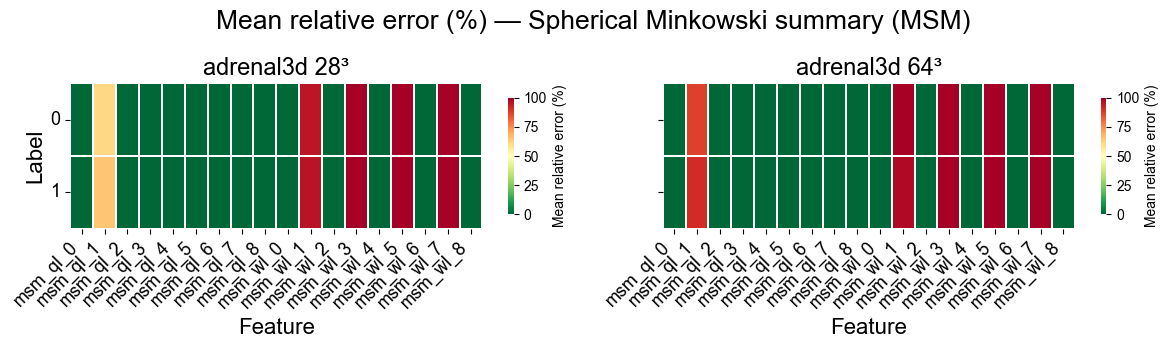


=== adrenal3d_28 ===
            max_rel_diff  mean_rel_diff
feature                                
w000           3.294e-10      7.349e-11
w100           4.716e-10      1.624e-10
w200           1.781e-06      6.845e-07
w300           1.922e+02      1.148e+01
w010_0         3.056e+01      2.998e-02
w010_1         1.500e+02      9.470e-02
w010_2         3.424e-05      1.662e-07
w110_0         4.609e-10      9.441e-11
w110_1         4.669e-10      8.717e-11
w110_2         4.765e-10      9.201e-11
w210_0         6.678e-04      3.290e-06
w210_1         1.876e-03      8.485e-06
w210_2         3.523e-03      1.373e-05
w310_0         5.522e-10      9.568e-11
w310_1         4.838e-10      8.985e-11
w310_2         9.892e-10      1.046e-10
w020_00        4.738e-10      1.064e-10
w020_01        4.847e-10      9.808e-11
w020_02        4.727e-10      9.587e-11
w020_11        4.863e-10      8.984e-11
w020_12        4.505e-10      9.668e-11
w020_22        4.590e-10      8.446e-11
w120_00        4.7

In [36]:
def rel_diff_summary(df_m, cols, eps=0.0):
    """Relative difference statistics between _k and _py columns across all meshes.

    Relative error per mesh = |k - py| / max(|k|, |py|) * 100
    Zero denominator (both k and py == 0) is treated as 0% error.

    Returns a DataFrame with max and mean relative difference per feature.
    """
    rows = []
    for col in cols:
        if f'{col}_k' not in df_m.columns or f'{col}_py' not in df_m.columns:
            continue
        k   = df_m[f'{col}_k']
        py  = df_m[f'{col}_py']
        denom = np.maximum(k.abs(), py.abs())
        rel   = np.where(denom == 0, 0.0, (k - py).abs() / denom * 100)
        rows.append({
            'feature':       col,
            'max_rel_diff':  rel.max(),
            'mean_rel_diff': rel.mean(),
        })
    return pd.DataFrame(rows).set_index('feature')


# ── Heatmap: mean relative difference per label × feature ─────────────────────
for slug, group_title, group_cols in _heatmap_groups:
    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(12, len(group_cols) * 0.4 + 4), 3.5),
        sharey=True,
    )
    for ax, channel in zip(axes, CHANNELS):
        df_m  = merged[channel]
        avail = [c for c in group_cols if f'{c}_k' in df_m.columns]

        heatmap_rows = []
        for lbl in sorted(df_m['label'].unique()):
            mask = df_m['label'] == lbl
            row  = {'label': lbl}
            for col in avail:
                k   = df_m.loc[mask, f'{col}_k']
                py  = df_m.loc[mask, f'{col}_py']
                denom = np.maximum(k.abs(), py.abs())
                rel   = np.where(denom == 0, 0.0, (k - py).abs() / denom * 100)
                row[col] = rel.mean()
            heatmap_rows.append(row)

        hmap_df = pd.DataFrame(heatmap_rows).set_index('label')[avail].fillna(0)

        seaborn.heatmap(
            hmap_df, annot=False, cmap='RdYlGn_r', linewidths=0.2, ax=ax,
            cbar_kws={'label': 'Mean relative error (%)', 'shrink': 0.8},
        )
        ax.set_title(f'adrenal3d {channel}³', fontsize=BASE_FONT)
        ax.set_xlabel('Feature', fontsize=BASE_FONT - 1)
        ax.set_ylabel('Label' if channel == CHANNELS[0] else '', fontsize=BASE_FONT - 1)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=BASE_FONT - 4)
        ax.tick_params(axis='y', rotation=0, labelsize=BASE_FONT - 4)

    fig.suptitle(f'Mean relative error (%) — {group_title}', fontsize=BASE_FONT + 2)
    plt.tight_layout()
    fig_path = os.path.join(FIGURES_PATH, f'heatmap_rel_{slug}.pdf')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {fig_path}')
    plt.show()


# ── Summary table ─────────────────────────────────────────────────────────────
for channel in CHANNELS:
    df_m    = merged[channel]
    summary = rel_diff_summary(df_m, compare_cols)
    print(f'\n=== adrenal3d_{channel} ===')
    print(summary.to_string(float_format='{:.3e}'.format))
    csv_path = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_rel_diff_summary.csv')
    summary.to_csv(csv_path)
    print(f'Saved → {csv_path}')

> **Note on relative error:** Relative error is computed as |k − py| / max(|k|, |py|) × 100.
> For features whose values are near zero on a given mesh (e.g. vector components aligned 
> with the coordinate axes, or odd-order MSM quantities), both implementations return 
> values close to machine epsilon, causing the denominator to approach zero and the relative 
> error to appear artificially large (up to 100%). These cases reflect floating-point 
> representation of true zeros rather than genuine disagreement. For such features, the 
> absolute error (typically < 1e-10) is the more informative quantity. 
>The spherical Minkowski summary quantities (`msm_ql` and `msm_wl`, l = 0, …, 8)
>show a distinct accuracy pattern. For `msm_ql` and even-l `msm_wl`, both
>mplementations agree to floating-point precision. For odd-l `msm_wl`
>(l = 1, 3, 5, 7), the Wigner 3j parity selection rule requires w_l = 0 exactly.
>pykarambola's Racah-formula implementation applies this rule analytically and
>returns exactly zero, whereas C++ karambola uses `gsl_sf_coupling_3j`, which
>evaluates numerically without an explicit parity check, producing spurious
>residuals of order 1e-8 to 1e-7 on the AdrenalMNIST3D meshes.